# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 43     |  |
| :-------------|:-------------|
| Christiaan Paardenkooper | 6453902 |
| Niels van Meurs | 6190243 |
| Jelle Kooloos | 6532241 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['kris', 'niels','jelle']

## Opdracht 1: Planning.

| Planning Groep: 43     |Tijdstip / Tijdspanne  |
|---|---|
| kalibratie mettingen | 11:30 |
| testen meet opstelling | 12:00 |
| iteratie 1 | 15:00 |
| itereren | 17:00 |
| groep aanwezig 1| 10:45|
| groep aanwezig 2| 13:45|
| Pauze 1| 12:45-13:45 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [43]<br>
<img src="kalibratie.jpg" width="400">

0.0345866701291786 -0.6979806784196922


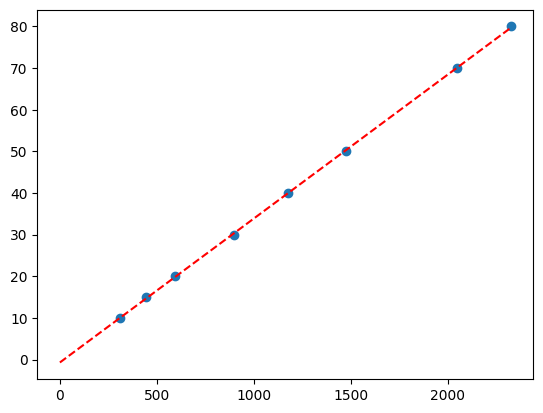

In [3]:
afstand = (310, 445, 593, 898, 1178, 1475, 2046, 2324)
mettingen = (10, 15, 20, 30, 40, 50, 70, 80) #cm

def kalibratie(afstand, a, b):
    return afstand*a + b
val, cov = curve_fit(kalibratie, afstand, mettingen)
a, b = val[0], val[1]
t = np.linspace(0, afstand[-1], 10000)
plt.scatter(afstand, mettingen)
plt.plot(t, kalibratie(t, a,b), 'r--')
print(a,b)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  46.02
1   0  30   0  20  46.70
2  40   0  30   0  44.62
3  30   0  20   0  45.10
4  10   0   0  10  21.34


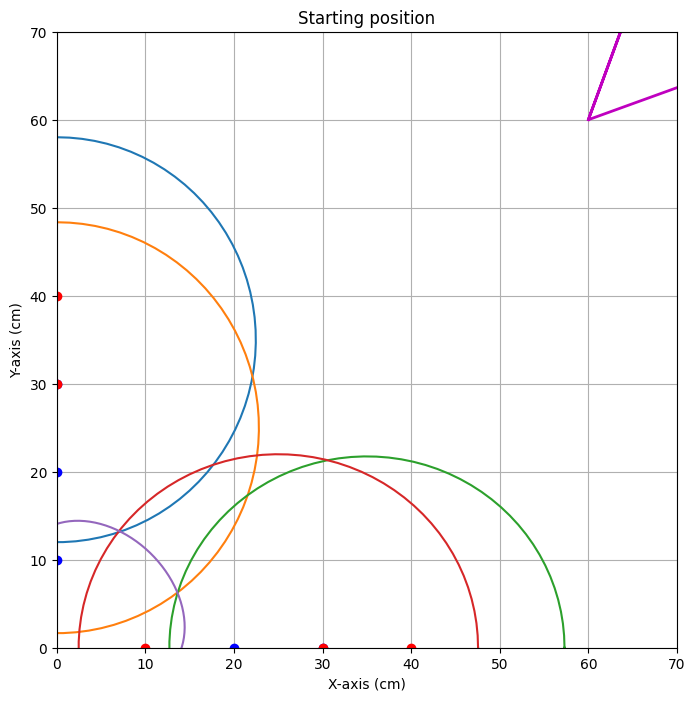


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=105.571


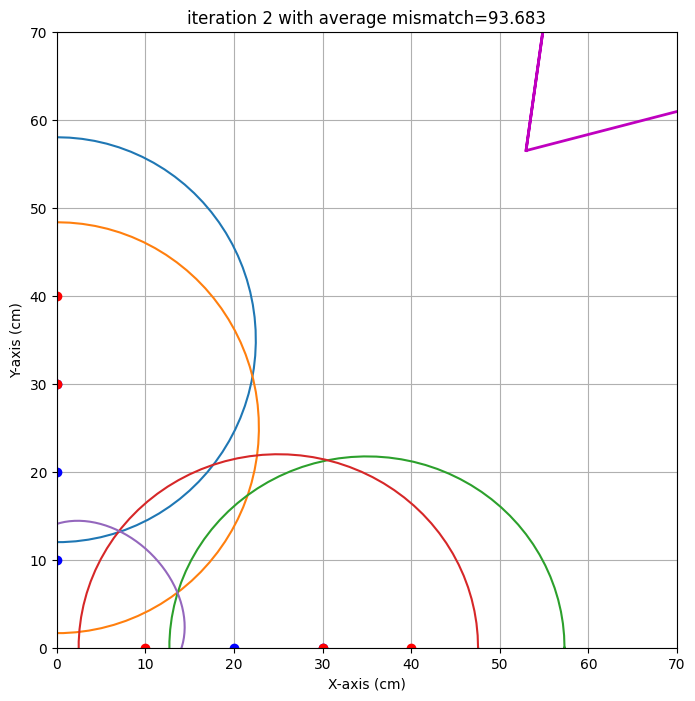

end iteration 2 with average mismatch=93.683


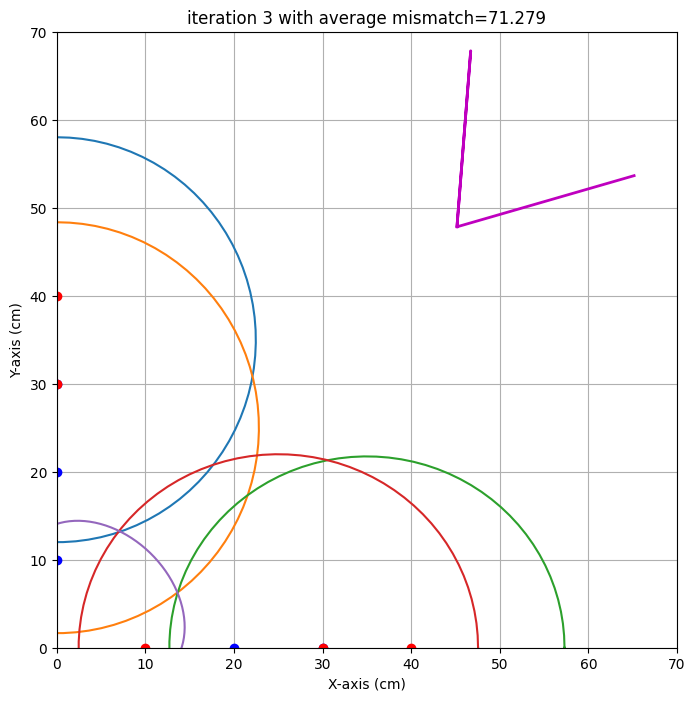

end iteration 3 with average mismatch=71.279


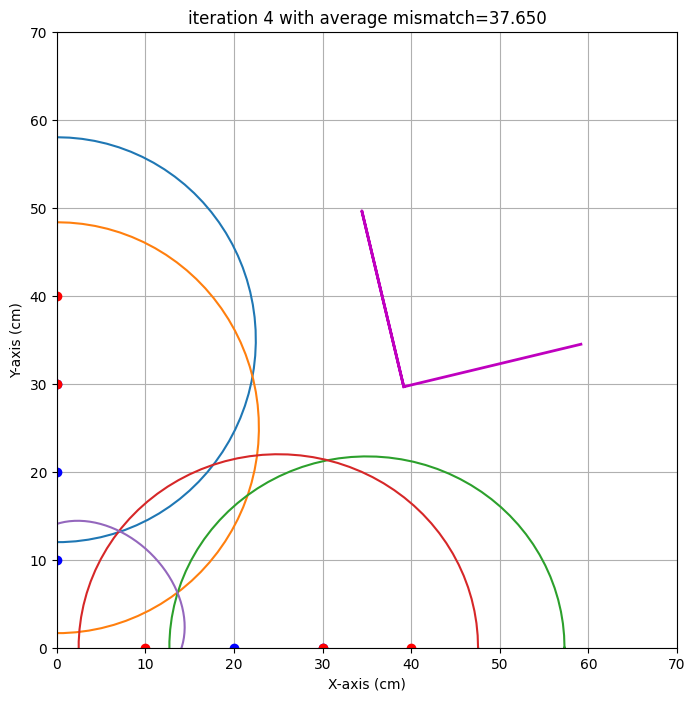

end iteration 4 with average mismatch=37.650


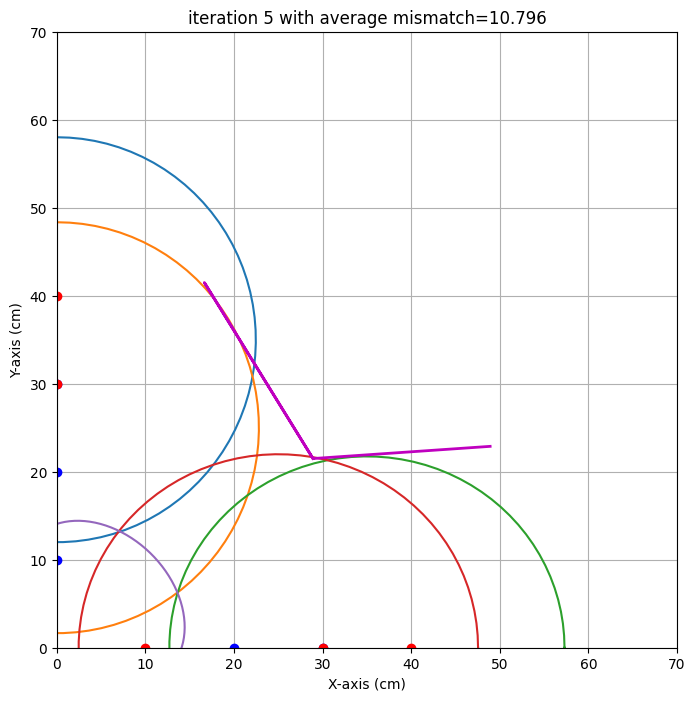

end iteration 5 with average mismatch=10.796
end iteration 6 with average mismatch=10.379
end iteration 7 with average mismatch= 9.925
end iteration 8 with average mismatch= 9.618
end iteration 9 with average mismatch= 9.319
end iteration 10 with average mismatch= 8.960
end iteration 11 with average mismatch= 8.812
end iteration 12 with average mismatch= 8.506
end iteration 13 with average mismatch= 7.991
end iteration 14 with average mismatch= 7.908
end iteration 15 with average mismatch= 7.861
end iteration 16 with average mismatch= 7.832
end iteration 17 with average mismatch= 7.810
end iteration 18 with average mismatch= 7.809
end iteration 19 with average mismatch= 7.809
end iteration 20 with average mismatch= 7.809
end iteration 21 with average mismatch= 7.809
end iteration 22 with average mismatch= 7.809
end iteration 23 with average mismatch= 7.809
end iteration 24 with average mismatch= 7.809
end iteration 25 with average mismatch= 7.809
end iteration 26 with average mismatch=

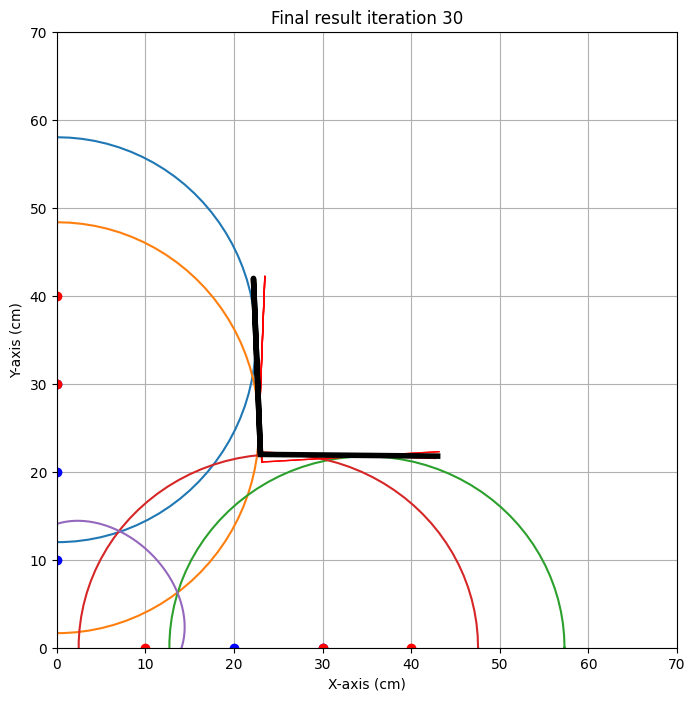

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30, 46.02],
    [0,30,0,20, 46.70],
    #[0,10,0,20, 139.4], 
    [40,0,30,0, 44.62], 
    [30,0,20,0, 45.10],
    #[10,0,20,0, 53.13],
    [10,0,0,10, 21.34]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 23.0 cm met een standaardafwijking van 0.3 cm 
y0: 22.0 cm met een standaardafwijking van 0.9 cm 
alpha: -0.6 graden met een standaardafwijking van 3.9 graad 
beta: -2.3 graden met een standaardafwijking van 4.4 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Christiaan]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="kris.jpeg" width="400">

<img src="iteratie_1.jpeg" width="400">

#### algoritme [Niels]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="niels.jpeg" width="400">

#### algoritme [Jelle]
Voeg een foto in van het algoritme van het derde groepslid
<img src="jelle.jpeg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':  49,
           'y0': 49,
           'alpha' : 30,
           'beta' : 180,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'kris' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 0, 45, 170],
    [45,0 , 35,0, 69.58],
    [45,0, 55, 0, 99.3],
    [0,45, 0,35,98.2],
    [0,45, 0,35, 89.2]
    ]),
       'niels' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,40,0, 162]
    [0, 50, 0, 60, 68.8], 
    [0, 40, 0, 50, 94],
    [35, 0, 40,0, 98],
    [20,0, 25,0, 97],
    [50,0,40,0,98.6]   
    ]),
       'jelle' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[40,0, 34,0, 179],
    #[0,34, 0, 40, 140],
    [0,50,0,56,62],
    [0,60, 0,56, 63],
    [50,0,59,0, 108],
    [40,0,64,0, 148]

    ])
      }

## Opdracht 7: Evaluatie.

kris
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  45   0  35   0  69.58
1  45   0  55   0  99.30
2   0  45   0  35  98.20
3   0  45   0  35  89.20


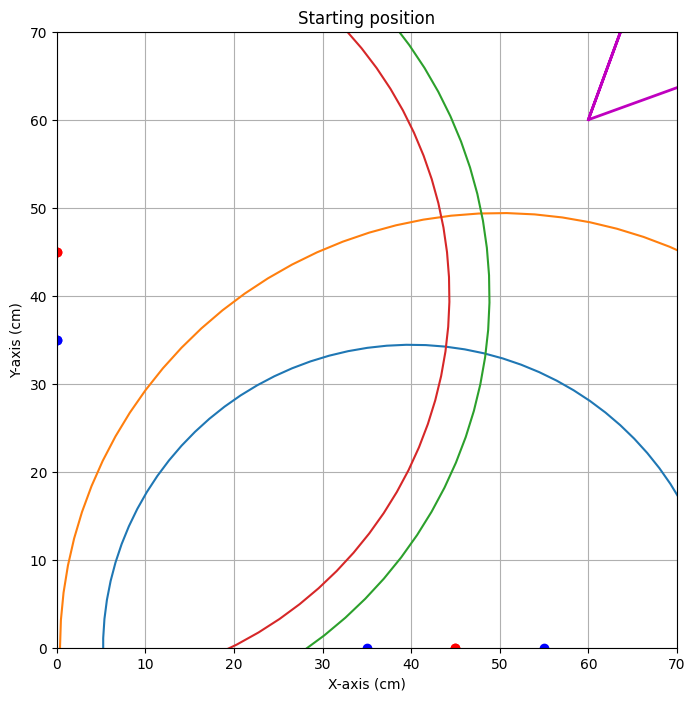


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=43.373


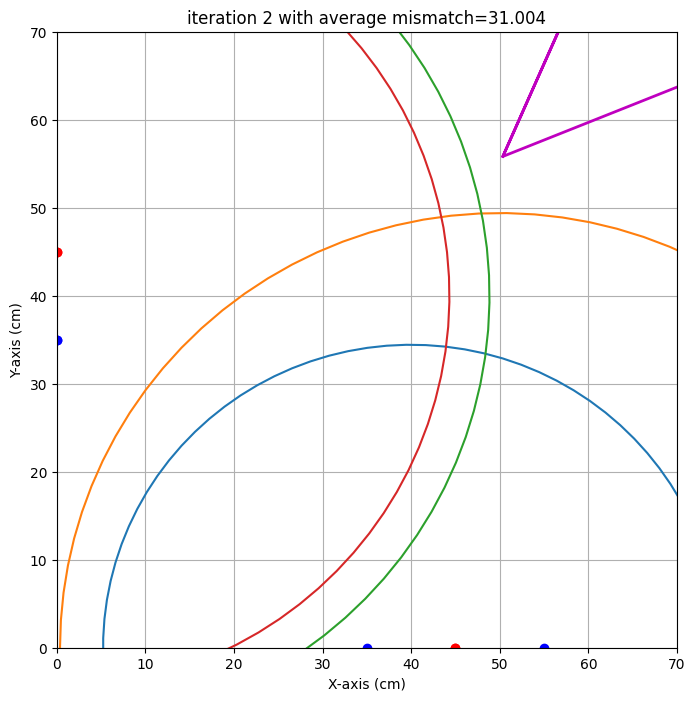

end iteration 2 with average mismatch=31.004


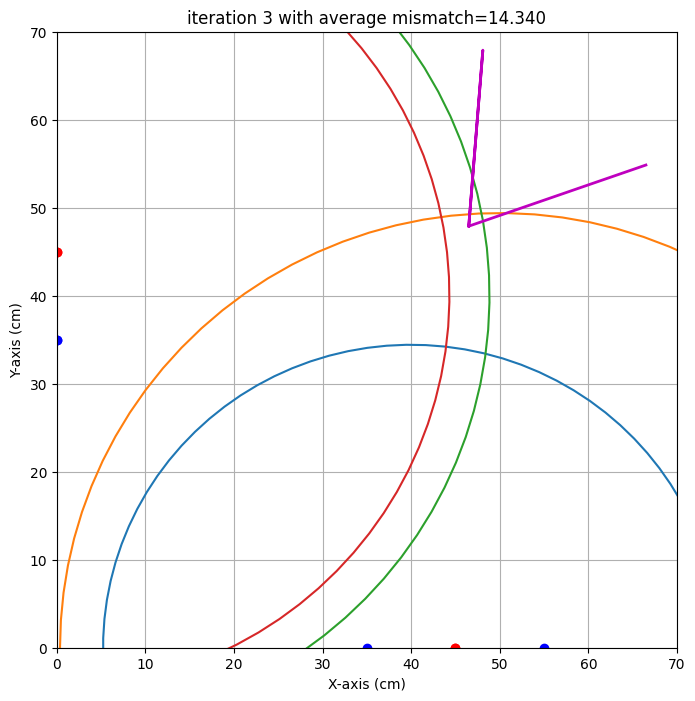

end iteration 3 with average mismatch=14.340


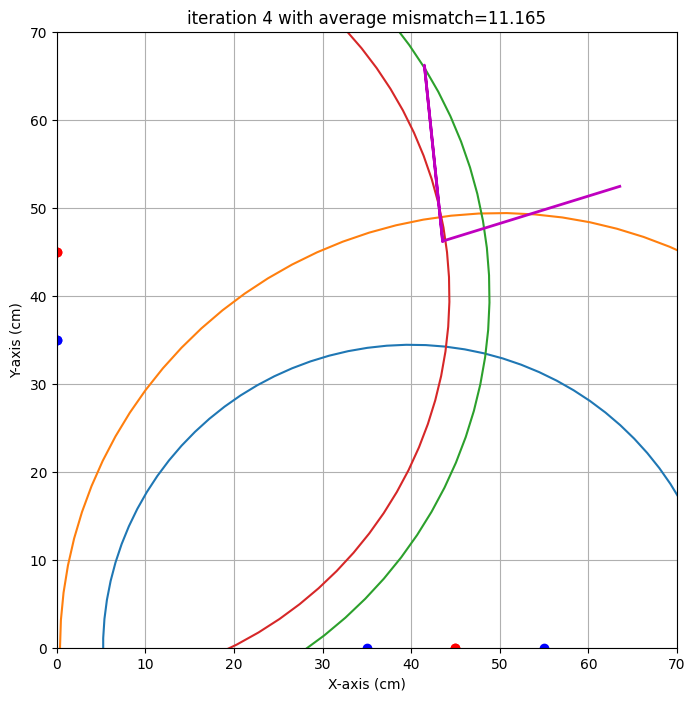

end iteration 4 with average mismatch=11.165
end iteration 5 with average mismatch=11.000
end iteration 6 with average mismatch=10.760
end iteration 7 with average mismatch=10.178


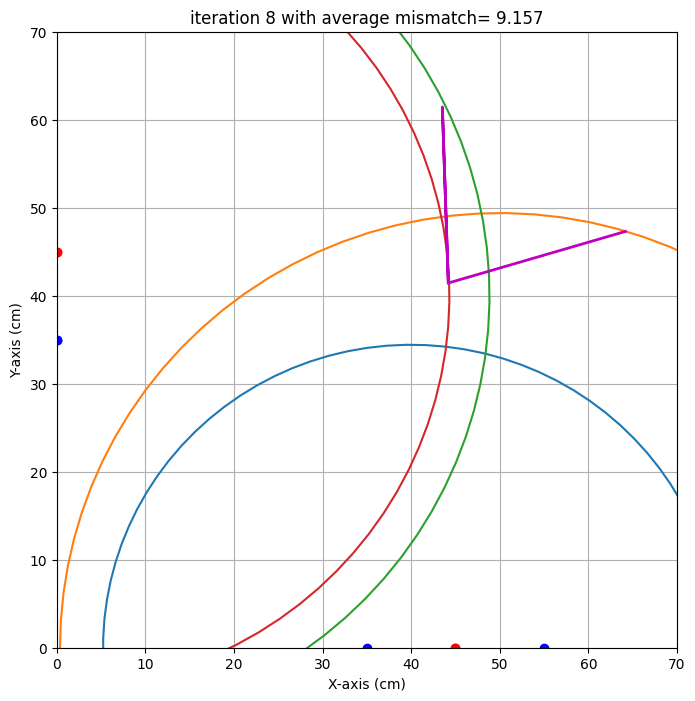

end iteration 8 with average mismatch= 9.157
end iteration 9 with average mismatch= 9.010
end iteration 10 with average mismatch= 8.404
end iteration 11 with average mismatch= 7.722


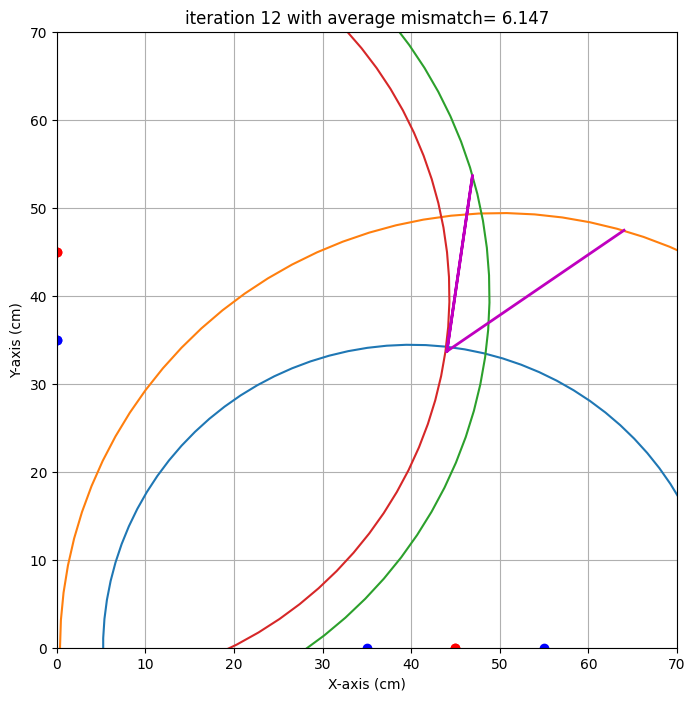

end iteration 12 with average mismatch= 6.147
end iteration 13 with average mismatch= 6.061
end iteration 14 with average mismatch= 5.656
end iteration 15 with average mismatch= 5.344


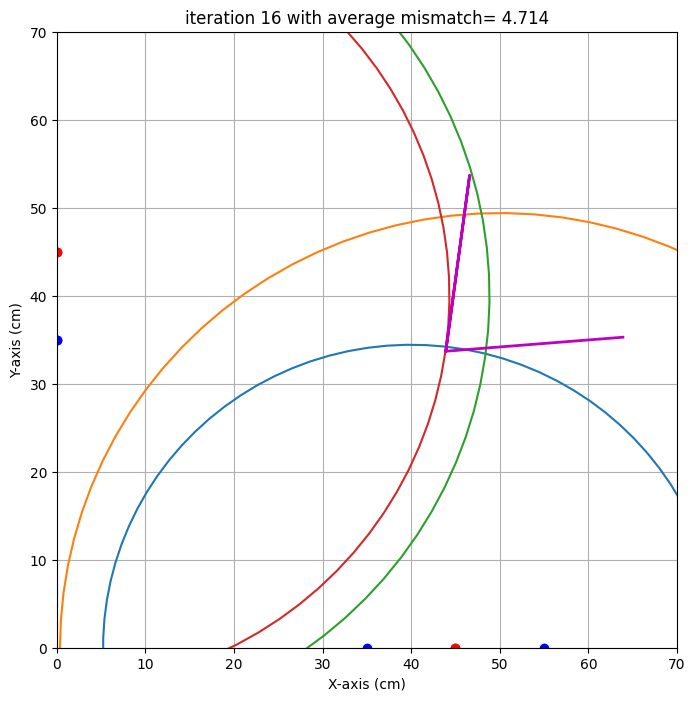

end iteration 16 with average mismatch= 4.714
end iteration 17 with average mismatch= 4.525
end iteration 18 with average mismatch= 4.183
end iteration 19 with average mismatch= 4.089
end iteration 20 with average mismatch= 4.027
end iteration 21 with average mismatch= 4.005
end iteration 22 with average mismatch= 4.005
end iteration 23 with average mismatch= 4.005
end iteration 24 with average mismatch= 3.942
end iteration 25 with average mismatch= 3.785
end iteration 26 with average mismatch= 3.785
end iteration 27 with average mismatch= 3.785
end iteration 28 with average mismatch= 3.751
end iteration 29 with average mismatch= 3.751
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 3.751
###############################################################################
end of iteration  30
Best alpha=  -9.32 with uncertainty=  10.81
Best b

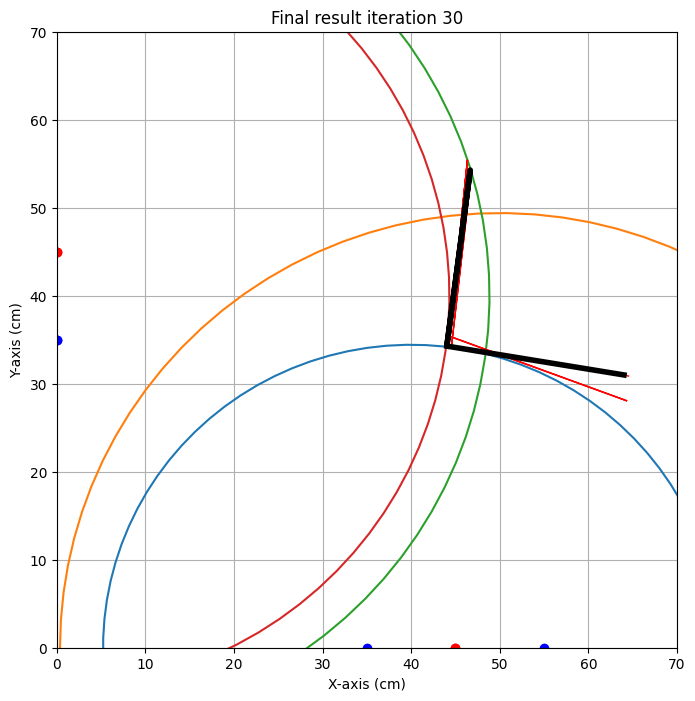

{'alpha': np.float64(-9.315863680665629), 'alpha_eps': np.float64(10.805638615529105), 'beta': np.float64(7.538553770570021), 'beta_eps': np.float64(1.7006317971452898), 'x0': np.float64(44.02209885971223), 'x0_eps': np.float64(0.5125968175715698), 'y0': np.float64(34.27787679151076), 'y0_eps': np.float64(1.121770143987689)}
niels
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  50   0  60  68.8
1   0  40   0  50  94.0
2  35   0  40   0  98.0
3  20   0  25   0  97.0
4  50   0  40   0  98.6


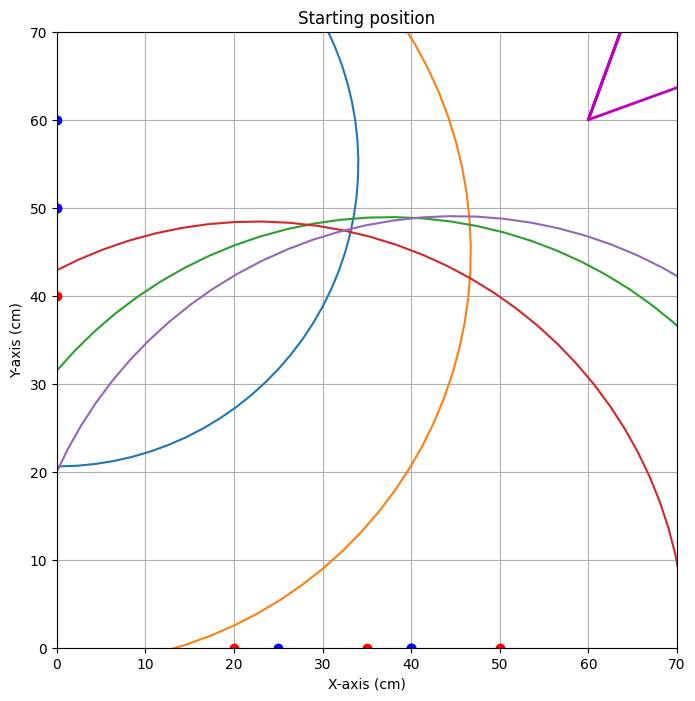


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=43.094


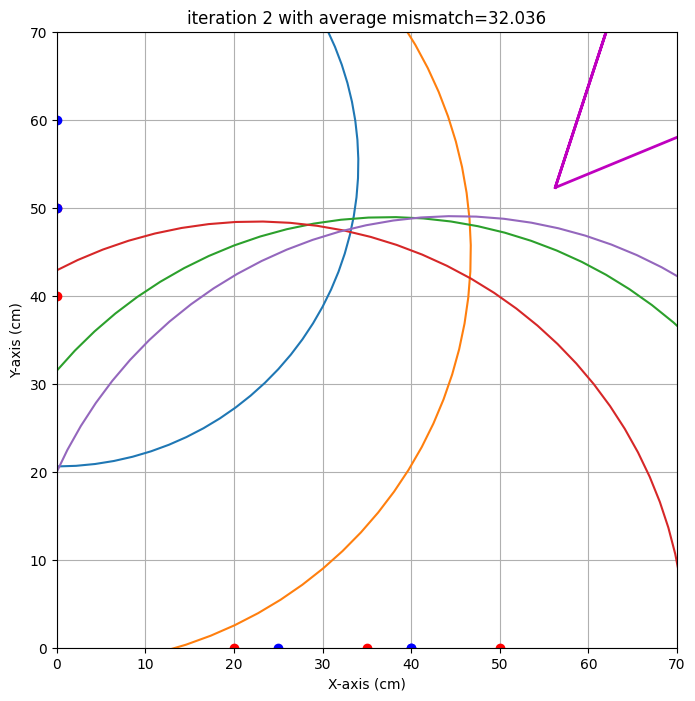

end iteration 2 with average mismatch=32.036


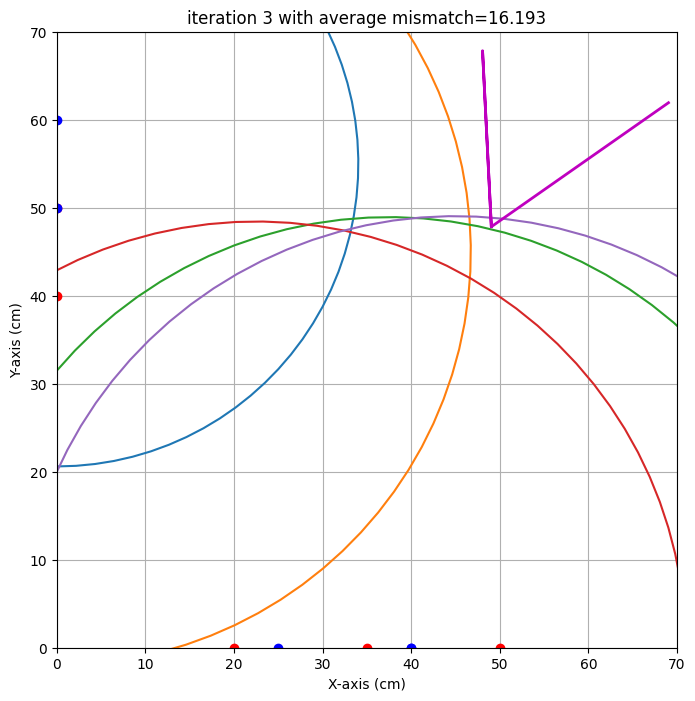

end iteration 3 with average mismatch=16.193


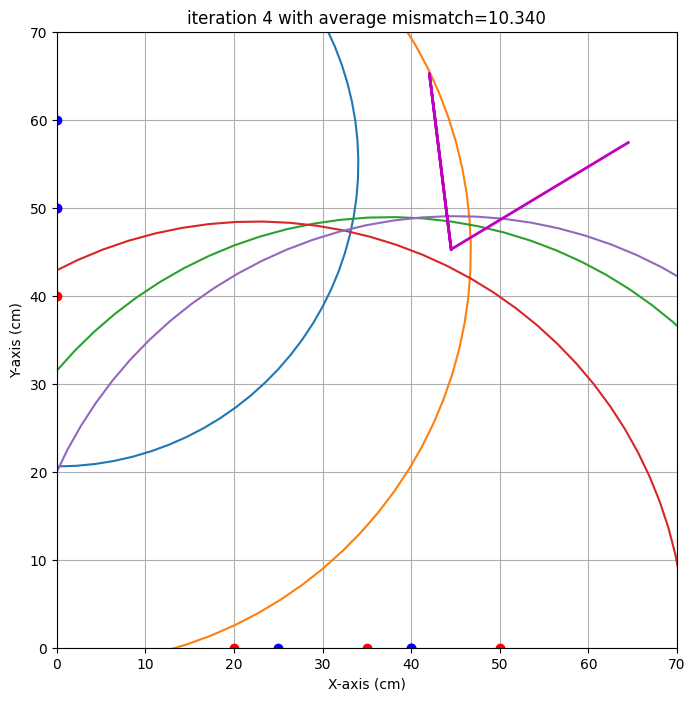

end iteration 4 with average mismatch=10.340
end iteration 5 with average mismatch=10.199
end iteration 6 with average mismatch= 9.939
end iteration 7 with average mismatch= 9.922
end iteration 8 with average mismatch= 9.922
end iteration 9 with average mismatch= 9.922
end iteration 10 with average mismatch= 9.709
end iteration 11 with average mismatch= 8.920


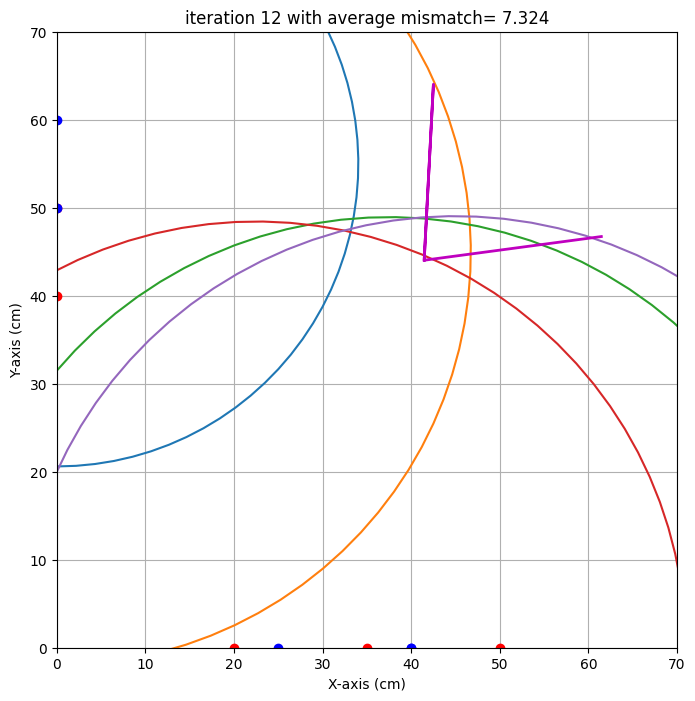

end iteration 12 with average mismatch= 7.324
end iteration 13 with average mismatch= 6.800
end iteration 14 with average mismatch= 6.800
end iteration 15 with average mismatch= 6.325


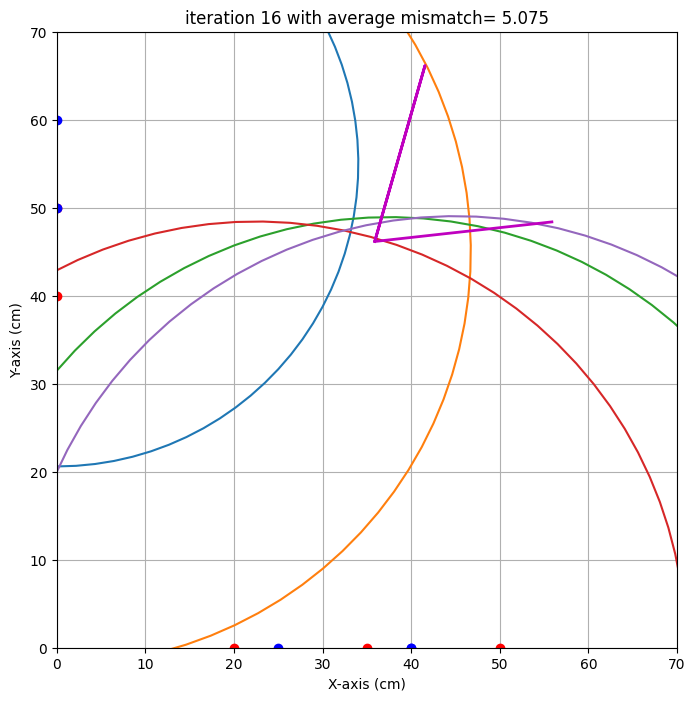

end iteration 16 with average mismatch= 5.075


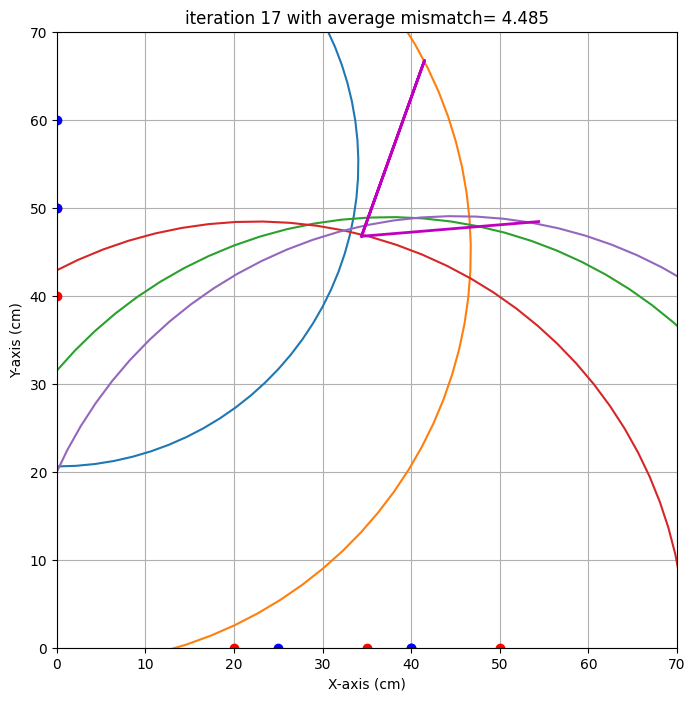

end iteration 17 with average mismatch= 4.485
end iteration 18 with average mismatch= 4.485


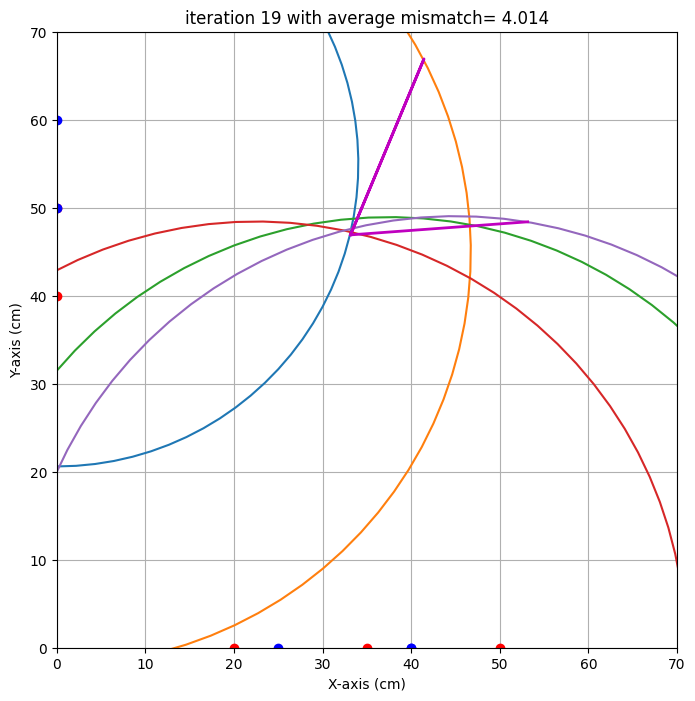

end iteration 19 with average mismatch= 4.014
end iteration 20 with average mismatch= 4.003
end iteration 21 with average mismatch= 4.003
end iteration 22 with average mismatch= 4.003
end iteration 23 with average mismatch= 3.957
end iteration 24 with average mismatch= 3.957
end iteration 25 with average mismatch= 3.948
end iteration 26 with average mismatch= 3.937
end iteration 27 with average mismatch= 3.936
end iteration 28 with average mismatch= 3.936
end iteration 29 with average mismatch= 3.936
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 3.936
###############################################################################
end of iteration  30
Best alpha=   4.20 with uncertainty=   2.84
Best beta =  22.28 with uncertainty=  13.57
Best x0   =  33.07 with uncertainty=   4.30
Best y0   =  46.96 with uncertainty=   0.54
##############################################################

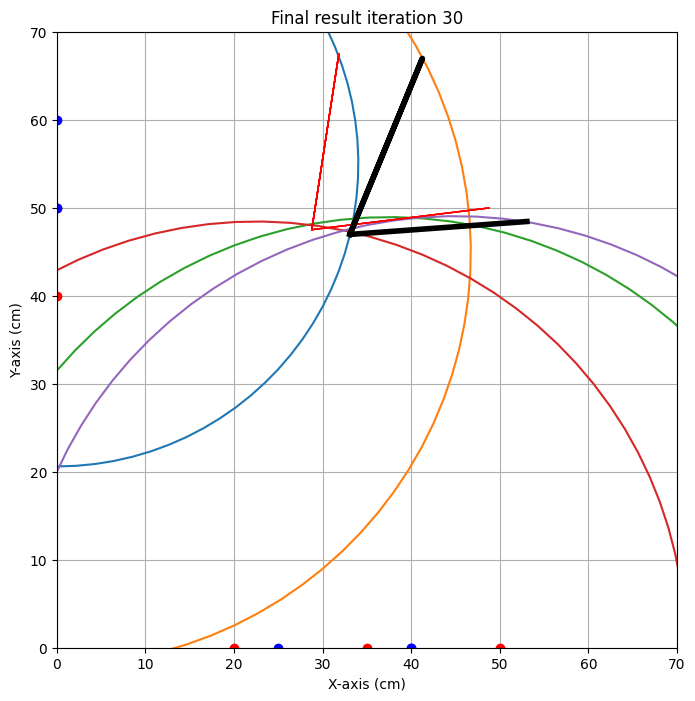

{'alpha': np.float64(4.1989139634988115), 'alpha_eps': np.float64(2.8381112910573725), 'beta': np.float64(22.275089690453), 'beta_eps': np.float64(13.571580333369594), 'x0': np.float64(33.06862117539305), 'x0_eps': np.float64(4.296089861350321), 'y0': np.float64(46.964053675247335), 'y0_eps': np.float64(0.5394685615330062)}
jelle
Running the imaging algorithm with the following data:
   xs  ys  xr  yr    R
0   0  50   0  56   62
1   0  60   0  56   63
2  50   0  59   0  108
3  40   0  64   0  148


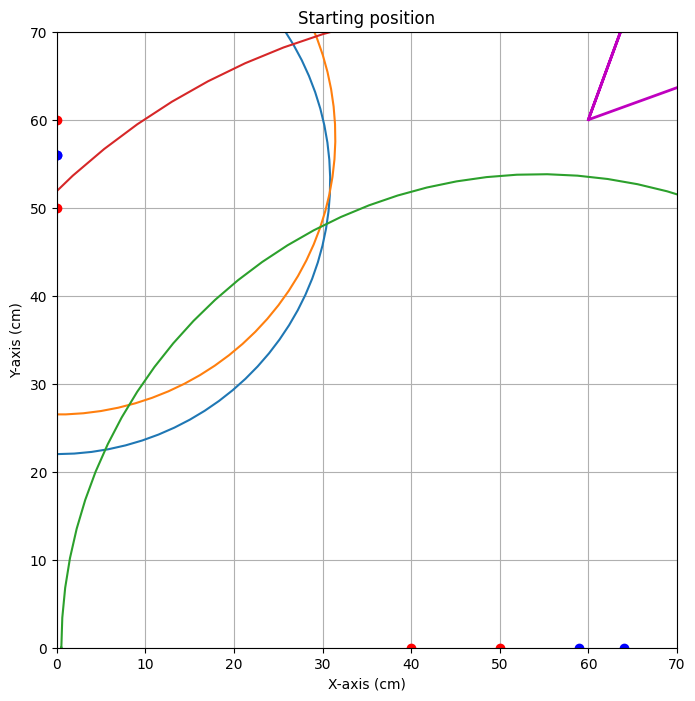


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=38.992


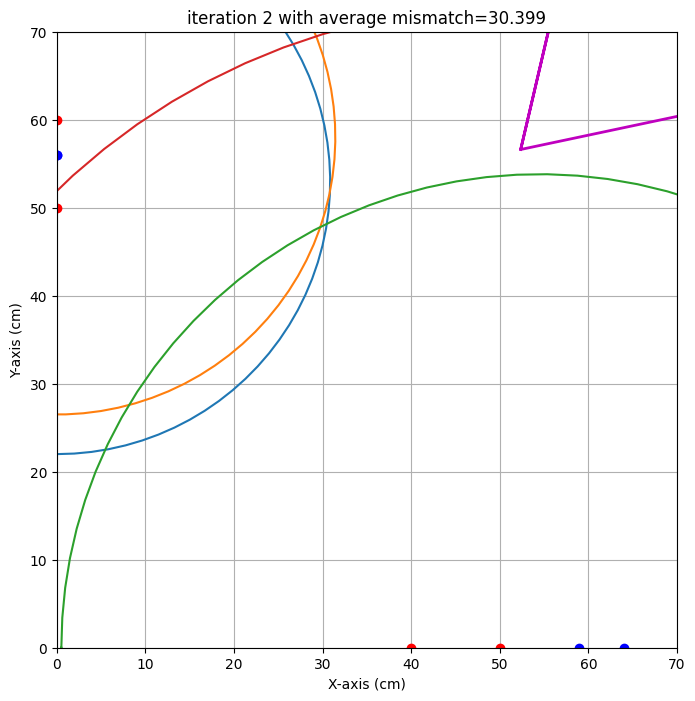

end iteration 2 with average mismatch=30.399


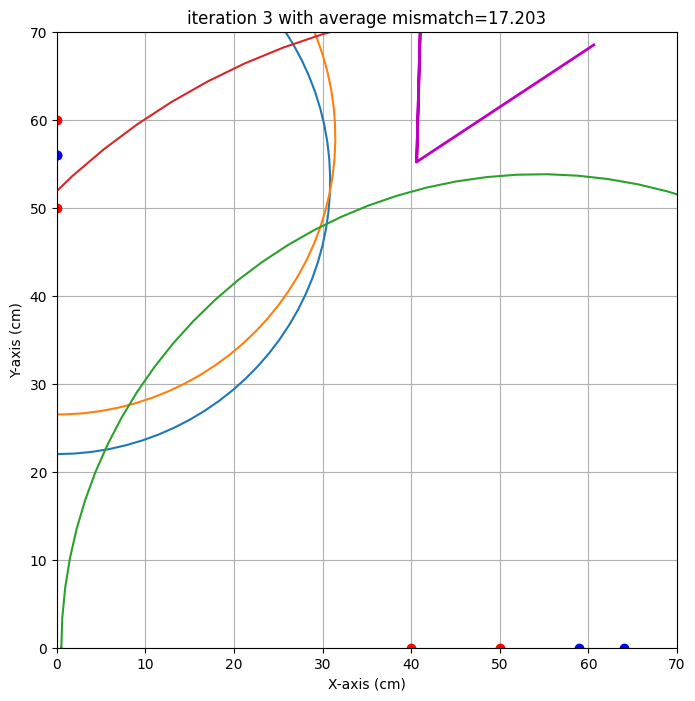

end iteration 3 with average mismatch=17.203


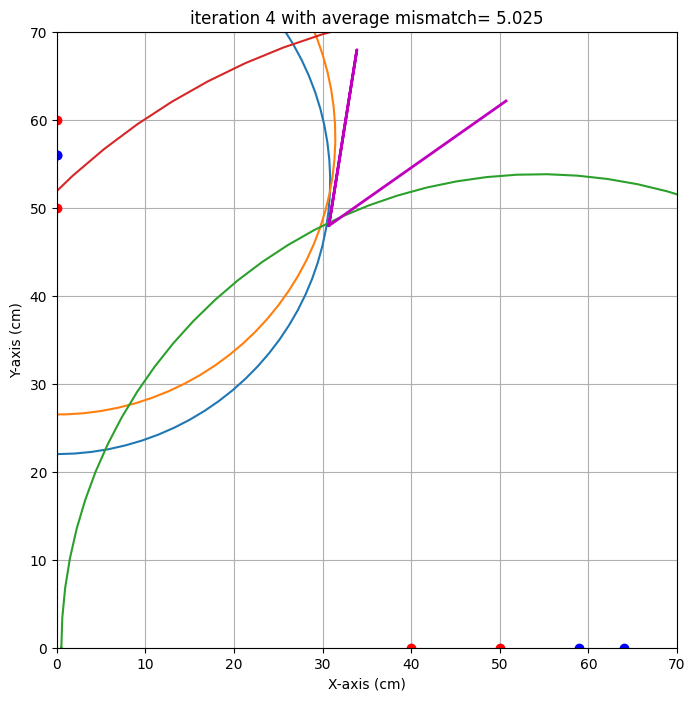

end iteration 4 with average mismatch= 5.025
end iteration 5 with average mismatch= 4.652
end iteration 6 with average mismatch= 4.573
end iteration 7 with average mismatch= 4.502
end iteration 8 with average mismatch= 4.395
end iteration 9 with average mismatch= 4.395
end iteration 10 with average mismatch= 4.395
end iteration 11 with average mismatch= 4.395
end iteration 12 with average mismatch= 4.395
end iteration 13 with average mismatch= 4.395
end iteration 14 with average mismatch= 4.294
end iteration 15 with average mismatch= 4.236
end iteration 16 with average mismatch= 3.883
end iteration 17 with average mismatch= 3.607
end iteration 18 with average mismatch= 3.385


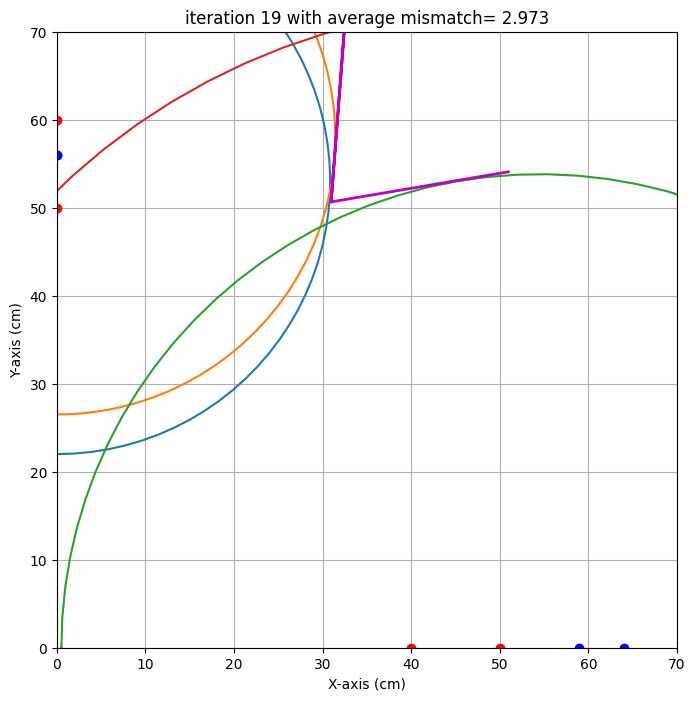

end iteration 19 with average mismatch= 2.973
end iteration 20 with average mismatch= 2.973
end iteration 21 with average mismatch= 2.852
end iteration 22 with average mismatch= 2.852
end iteration 23 with average mismatch= 2.852
end iteration 24 with average mismatch= 2.852
end iteration 25 with average mismatch= 2.852
end iteration 26 with average mismatch= 2.852
end iteration 27 with average mismatch= 2.852
end iteration 28 with average mismatch= 2.852
end iteration 29 with average mismatch= 2.852
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 2.852
###############################################################################
end of iteration  30
Best alpha=  11.18 with uncertainty=   2.13
Best beta =   2.86 with uncertainty=   5.68
Best x0   =  31.09 with uncertainty=   0.44
Best y0   =  50.33 with uncertainty=   0.29
##############################################################

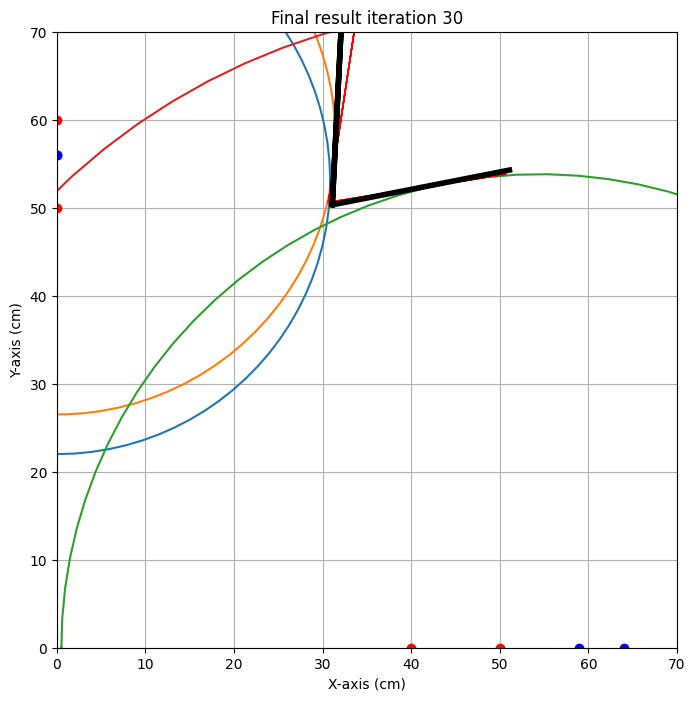

{'alpha': np.float64(11.176479585126126), 'alpha_eps': np.float64(2.1340491063091047), 'beta': np.float64(2.8620287447877604), 'beta_eps': np.float64(5.679488644449018), 'x0': np.float64(31.08983690700334), 'x0_eps': np.float64(0.4375315834661784), 'y0': np.float64(50.32776321874337), 'y0_eps': np.float64(0.29182149650030453)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

kris 
x0 target is : 49.0. Gevonden waarde: 44.0 cm met een standaardafwijking van 0.5 cm 
y0 target is : 49.0. Gevonden waarde: 34.3 cm met een standaardafwijking van 1.1 cm 
alpha target is : 30.0. Gevonden waarde: -9.3 graden met een standaardafwijking van 10.8 graad 
beta target is : 180.0. Gevonden waarde: 7.5 graden met een standaardafwijking van 1.7 graad 

niels 
x0 target is : 49.0. Gevonden waarde: 33.1 cm met een standaardafwijking van 4.3 cm 
y0 target is : 49.0. Gevonden waarde: 47.0 cm met een standaardafwijking van 0.5 cm 
alpha target is : 30.0. Gevonden waarde: 4.2 graden met een standaardafwijking van 2.8 graad 
beta target is : 180.0. Gevonden waarde: 22.3 graden met een standaardafwijking van 13.6 graad 

jelle 
x0 target is : 49.0. Gevonden waarde: 31.1 cm met een standaardafwijking van 0.4 cm 
y0 target is : 49.0. Gevonden waarde: 50.3 cm met een standaardafwijking van 0.3 cm 
alpha target is : 30.0. Gevonden waarde: 11.2 graden met een standaardafwijking van 2.1 

## Opdracht 8: Iteratie1+.14:37
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](iteratie_2.jpeg)
Figuur: ![Alt](iteratie_3.jpeg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  84.5
1   0  45   0  55  68.6
2   0  50   0  60  69.3
3  38   0  48   0  84.2


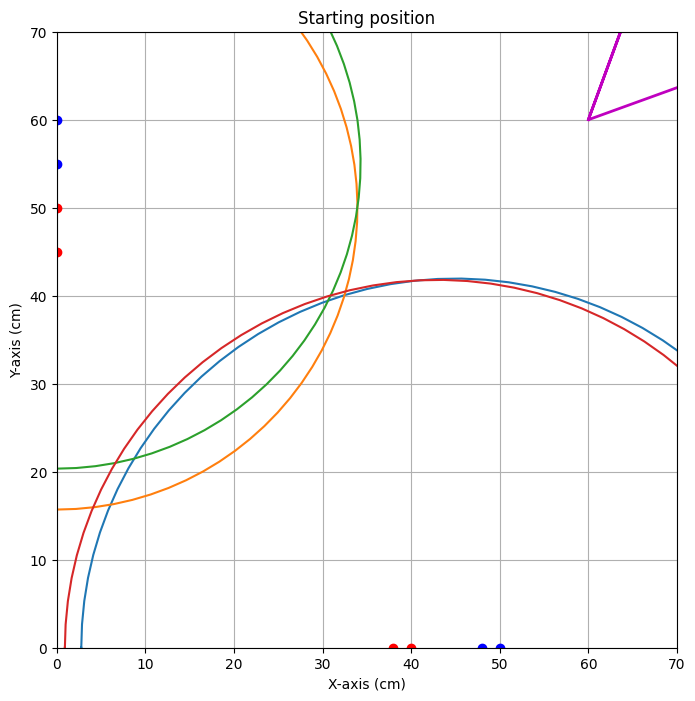


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.318


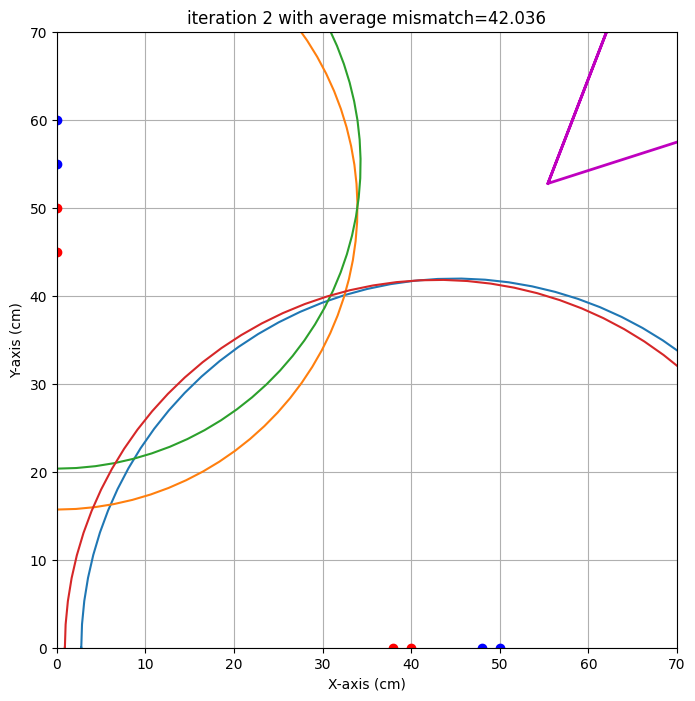

end iteration 2 with average mismatch=42.036


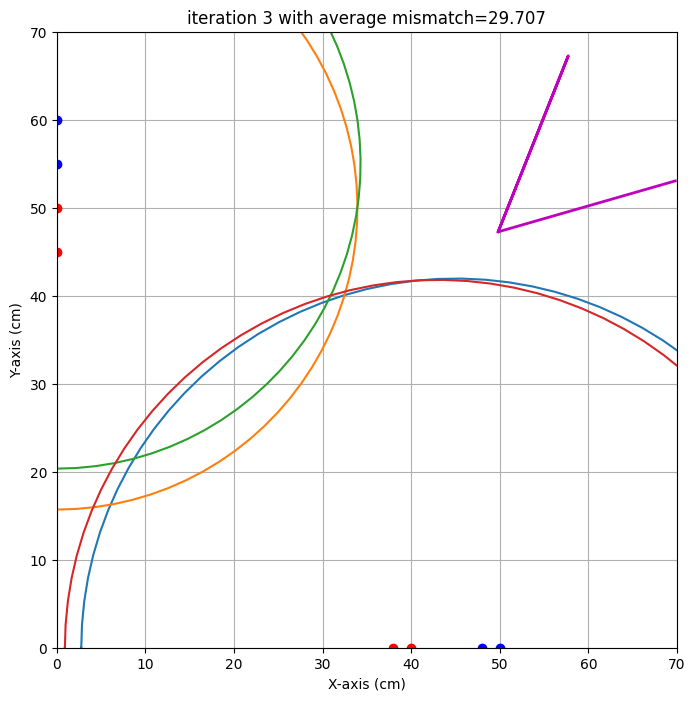

end iteration 3 with average mismatch=29.707


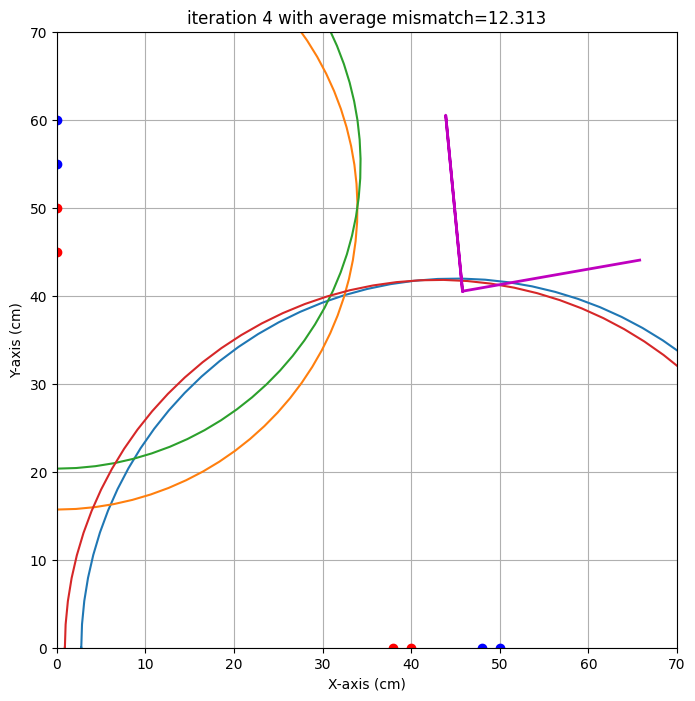

end iteration 4 with average mismatch=12.313


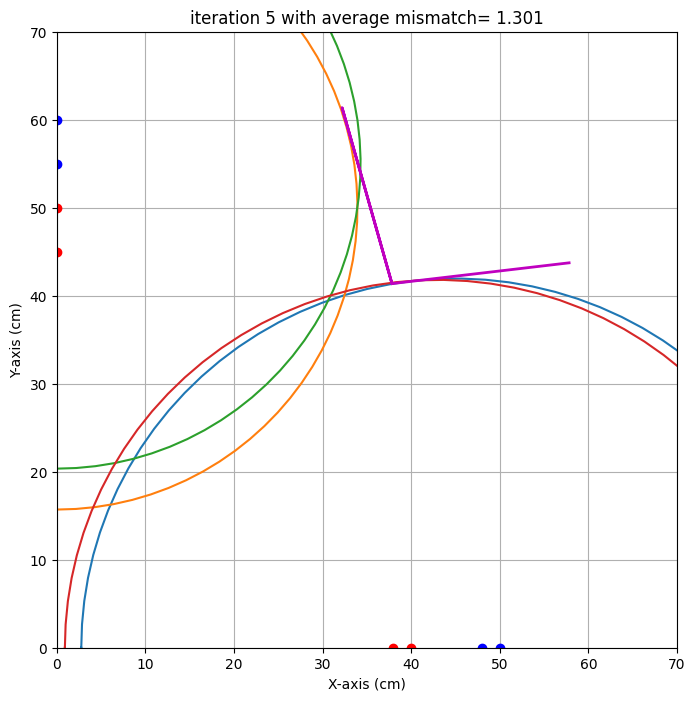

end iteration 5 with average mismatch= 1.301
end iteration 6 with average mismatch= 1.181
end iteration 7 with average mismatch= 1.076


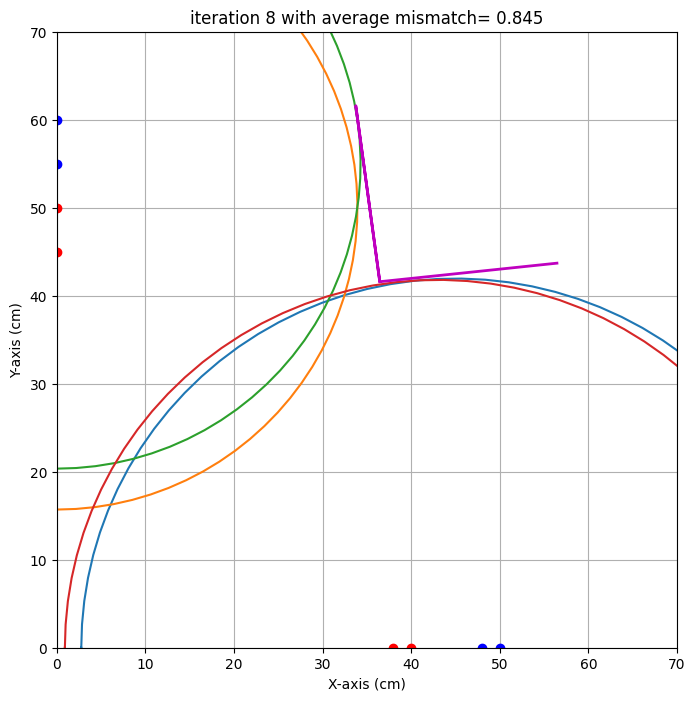

end iteration 8 with average mismatch= 0.845


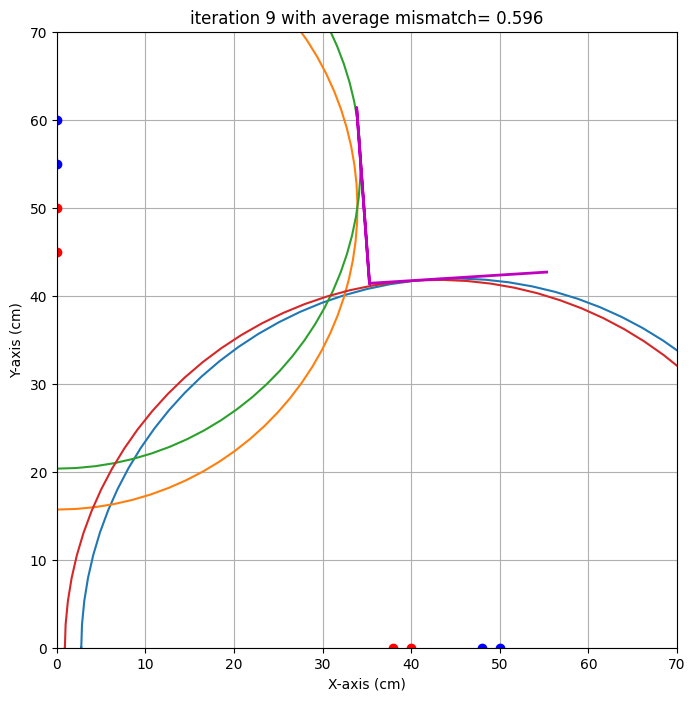

end iteration 9 with average mismatch= 0.596


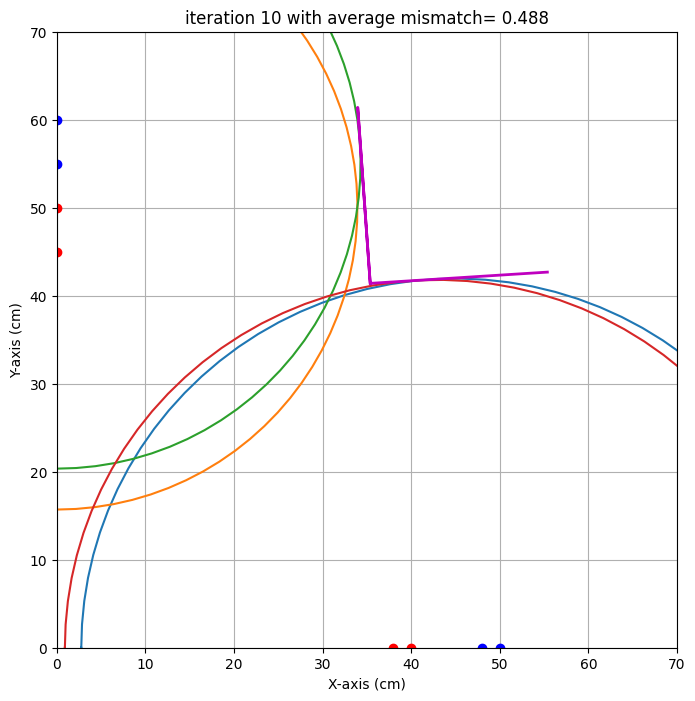

end iteration 10 with average mismatch= 0.488
end iteration 11 with average mismatch= 0.458
end iteration 12 with average mismatch= 0.448
end iteration 13 with average mismatch= 0.448
end iteration 14 with average mismatch= 0.448


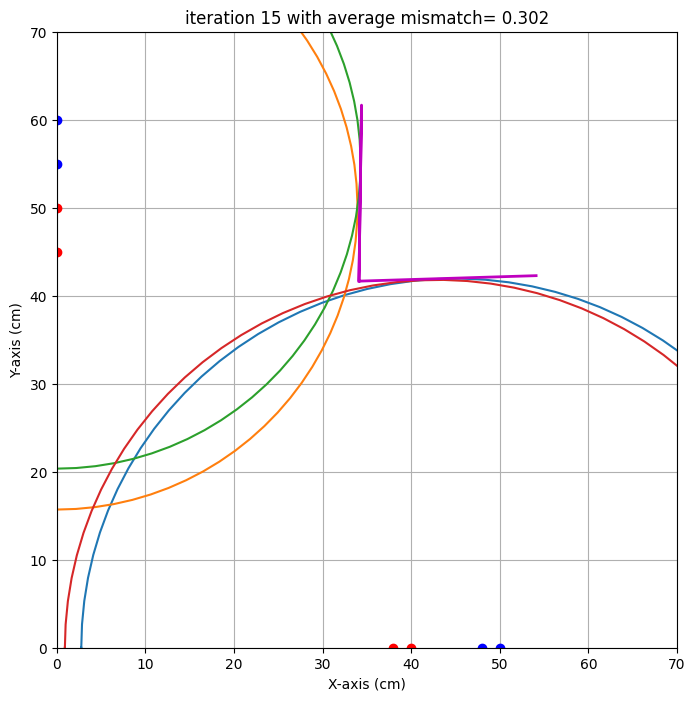

end iteration 15 with average mismatch= 0.302
end iteration 16 with average mismatch= 0.288
end iteration 17 with average mismatch= 0.283
end iteration 18 with average mismatch= 0.282
end iteration 19 with average mismatch= 0.282
end iteration 20 with average mismatch= 0.282
end iteration 21 with average mismatch= 0.282
end iteration 22 with average mismatch= 0.259


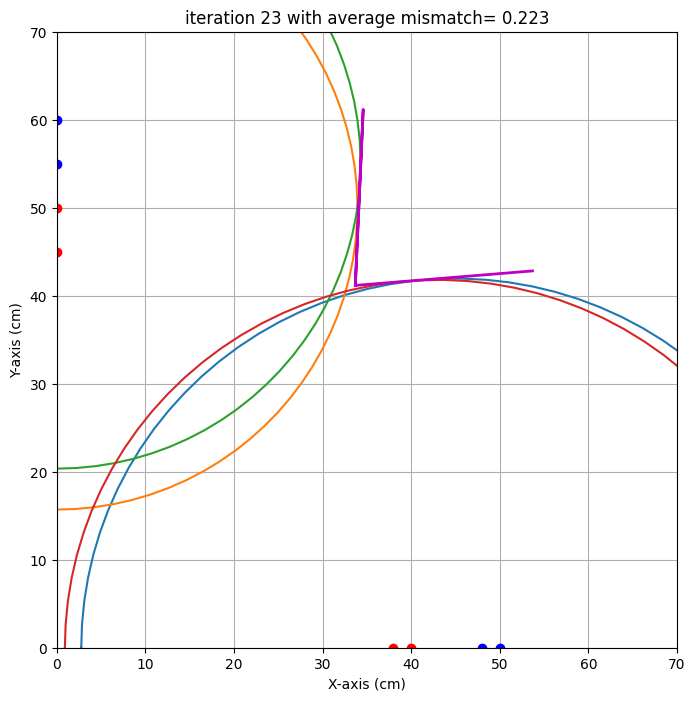

end iteration 23 with average mismatch= 0.223
end iteration 24 with average mismatch= 0.223
end iteration 25 with average mismatch= 0.223
end iteration 26 with average mismatch= 0.217
end iteration 27 with average mismatch= 0.214
end iteration 28 with average mismatch= 0.214


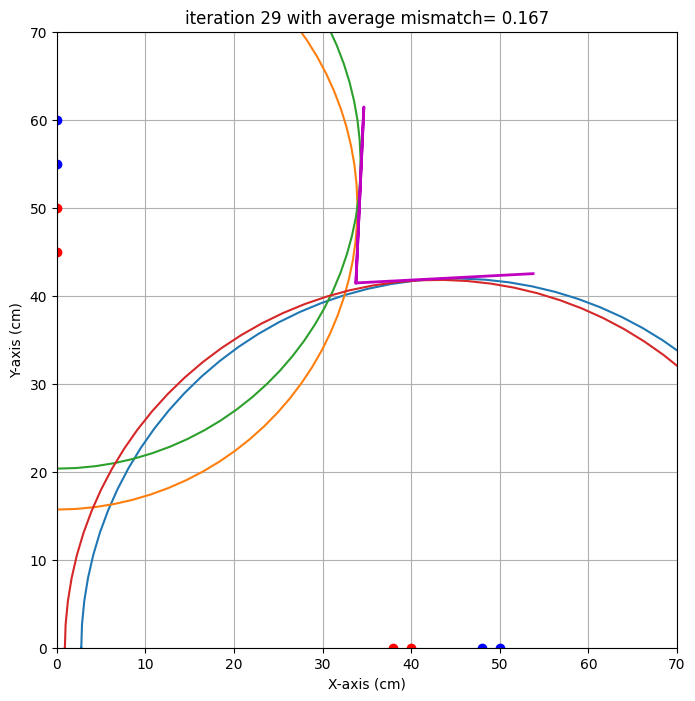

end iteration 29 with average mismatch= 0.167
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


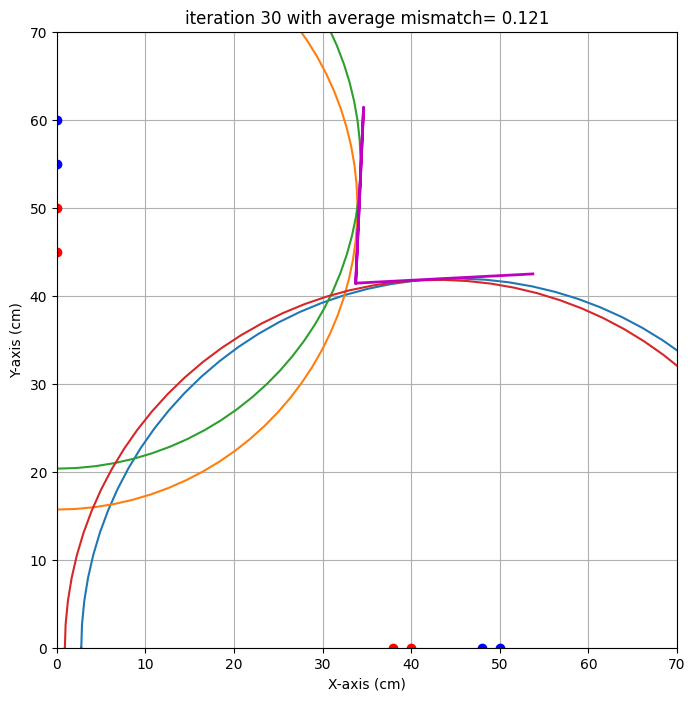

end iteration 30 with average mismatch= 0.121
###############################################################################
end of iteration  30
Best alpha=   3.01 with uncertainty=   7.02
Best beta =   2.55 with uncertainty=   5.56
Best x0   =  33.74 with uncertainty=   1.30
Best y0   =  41.43 with uncertainty=   1.07
###############################################################################


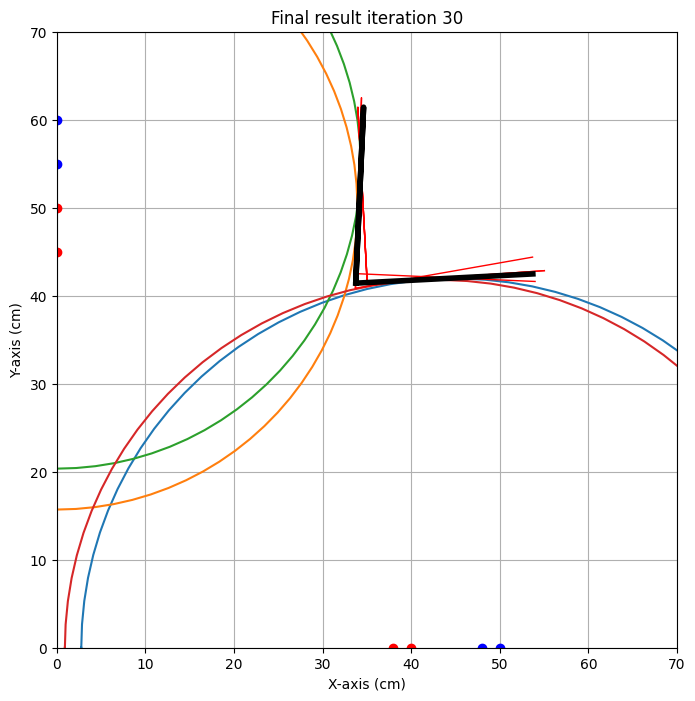

{'alpha': np.float64(3.005751018308893), 'alpha_eps': np.float64(7.0186597427546475), 'beta': np.float64(2.5486443038024573), 'beta_eps': np.float64(5.564538851727126), 'x0': np.float64(33.736493977067404), 'x0_eps': np.float64(1.298285528740145), 'y0': np.float64(41.426880199354436), 'y0_eps': np.float64(1.0726190717981936)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  92.3
1   0  50   0  60  68.0
2   0  55   0  65  65.7
3  45   0  55   0  91.7


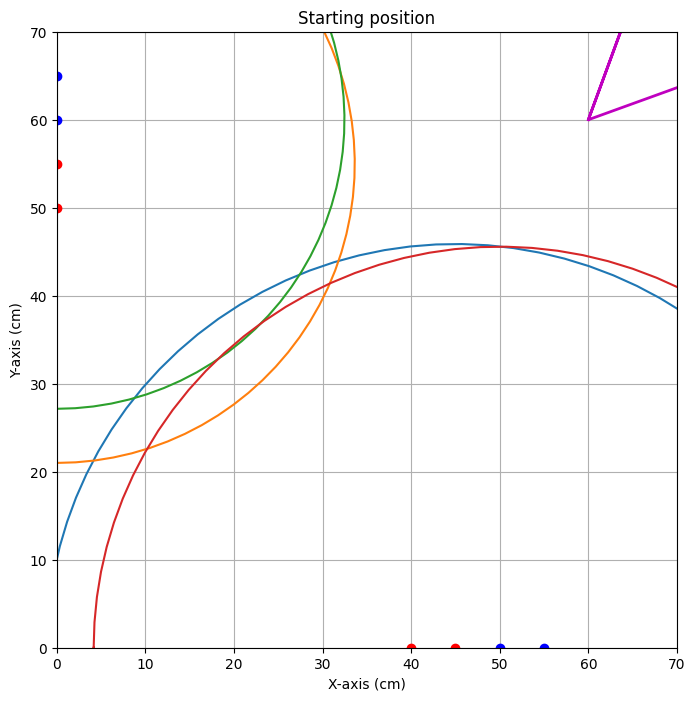


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=48.004


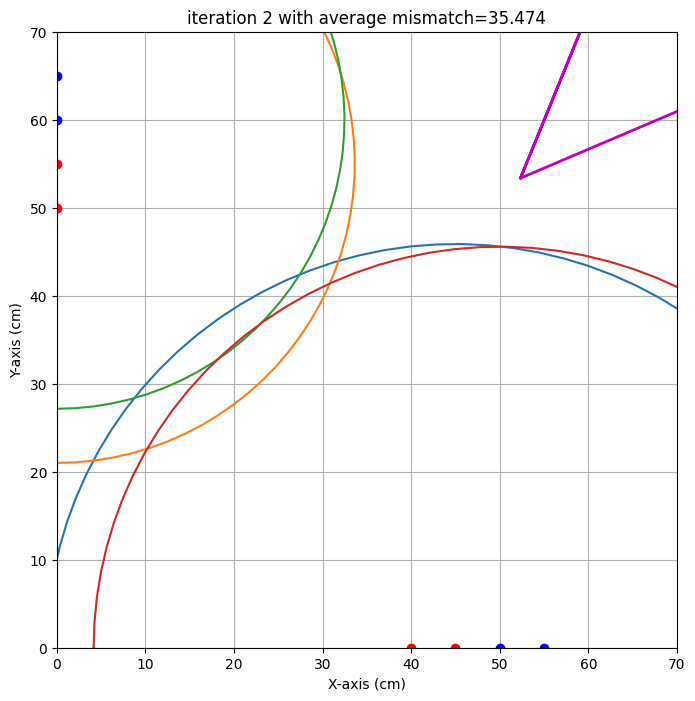

end iteration 2 with average mismatch=35.474


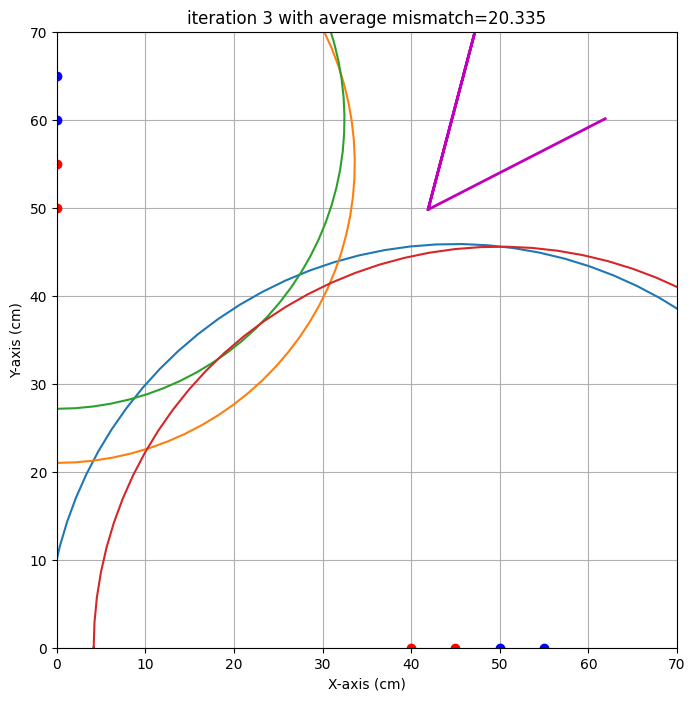

end iteration 3 with average mismatch=20.335


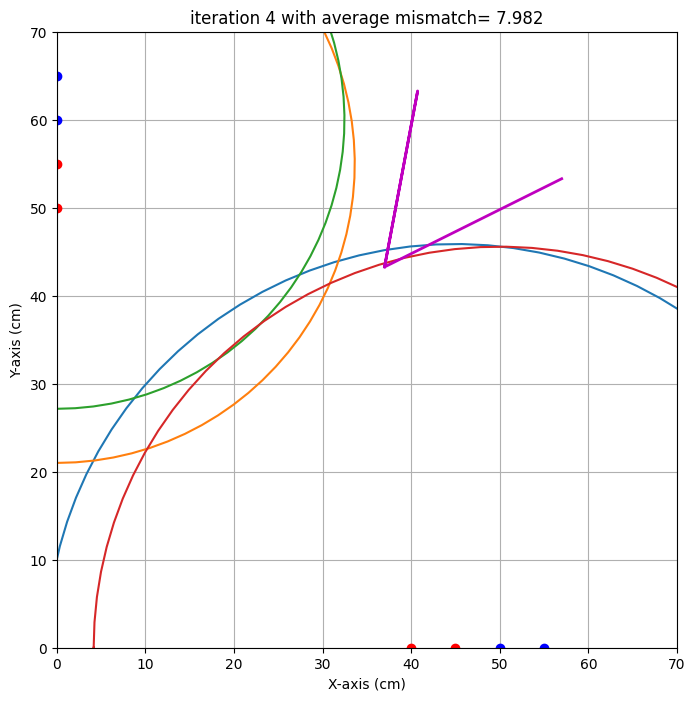

end iteration 4 with average mismatch= 7.982


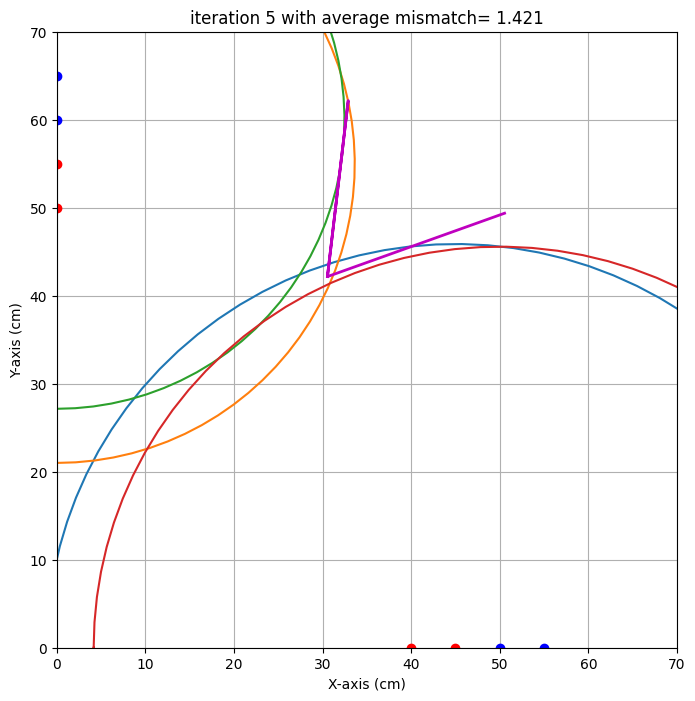

end iteration 5 with average mismatch= 1.421
end iteration 6 with average mismatch= 1.318


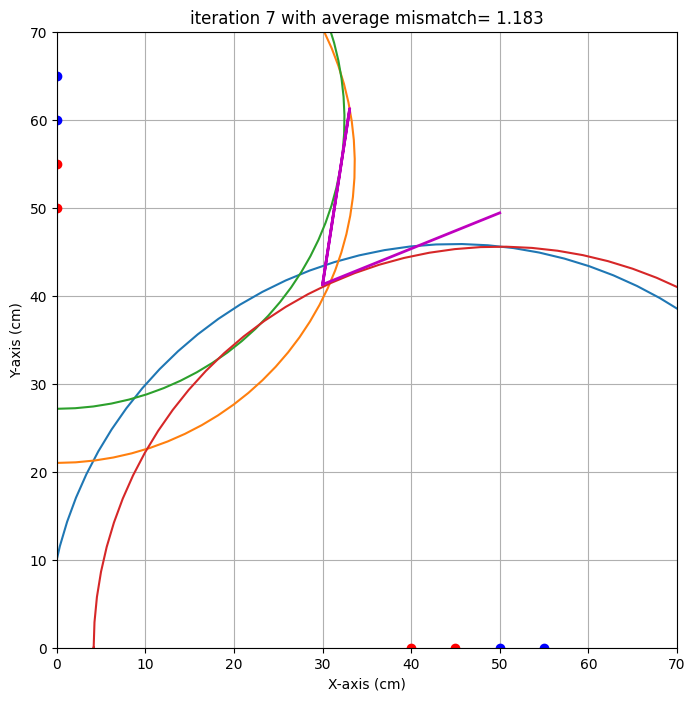

end iteration 7 with average mismatch= 1.183
end iteration 8 with average mismatch= 1.108
end iteration 9 with average mismatch= 1.102
end iteration 10 with average mismatch= 1.083
end iteration 11 with average mismatch= 1.083
end iteration 12 with average mismatch= 1.083
end iteration 13 with average mismatch= 1.083
end iteration 14 with average mismatch= 1.083
end iteration 15 with average mismatch= 1.083
end iteration 16 with average mismatch= 1.083
end iteration 17 with average mismatch= 1.083
end iteration 18 with average mismatch= 1.083
end iteration 19 with average mismatch= 1.071
end iteration 20 with average mismatch= 1.069
end iteration 21 with average mismatch= 1.069
end iteration 22 with average mismatch= 1.050
end iteration 23 with average mismatch= 1.050
end iteration 24 with average mismatch= 1.050
end iteration 25 with average mismatch= 1.050


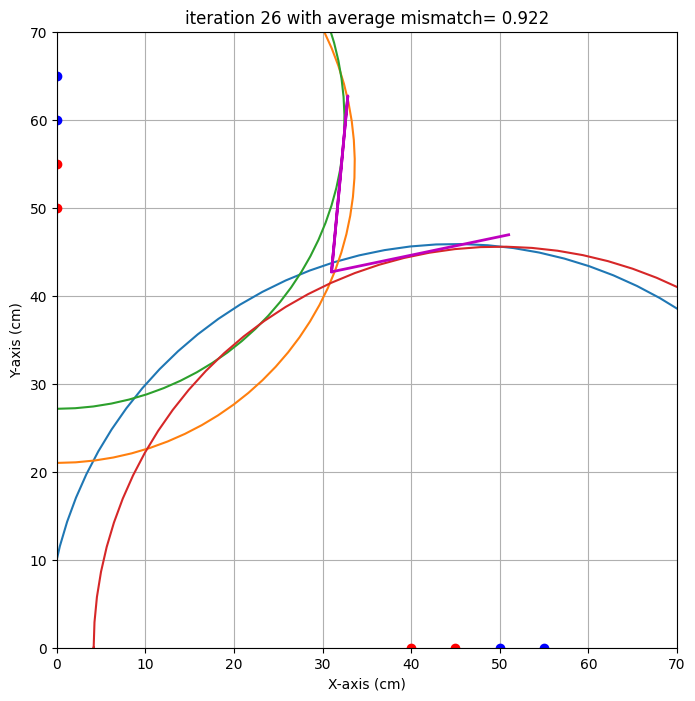

end iteration 26 with average mismatch= 0.922
end iteration 27 with average mismatch= 0.901
end iteration 28 with average mismatch= 0.882
end iteration 29 with average mismatch= 0.877
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


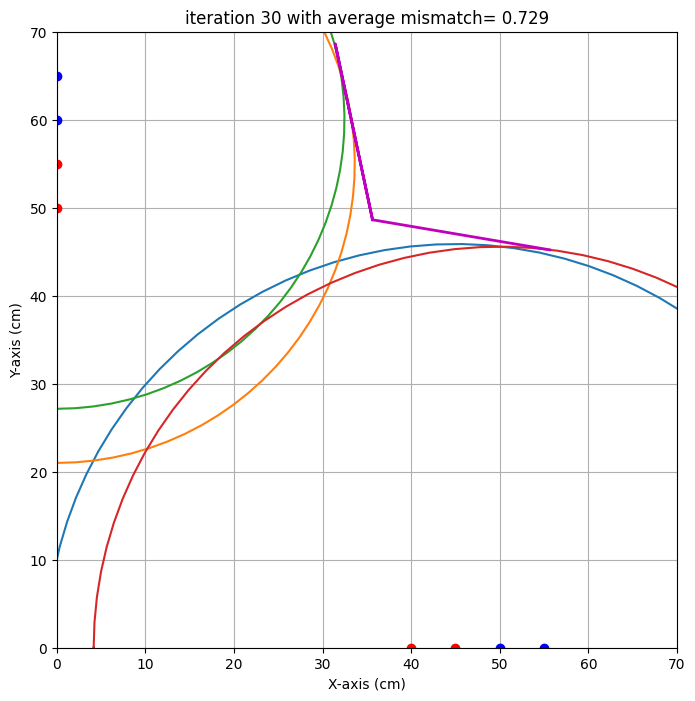

end iteration 30 with average mismatch= 0.729
###############################################################################
end of iteration  30
Best alpha=  -9.69 with uncertainty=  10.02
Best beta = -11.90 with uncertainty=  10.83
Best x0   =  35.64 with uncertainty=   1.73
Best y0   =  48.63 with uncertainty=   3.13
###############################################################################


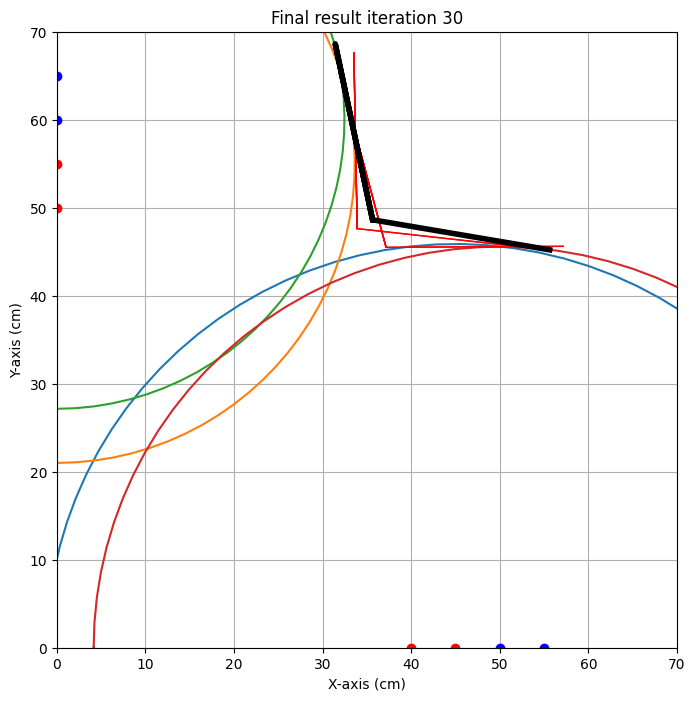

{'alpha': np.float64(-9.686073950326936), 'alpha_eps': np.float64(10.022046987163117), 'beta': np.float64(-11.902436404216408), 'beta_eps': np.float64(10.829436555728662), 'x0': np.float64(35.63570448947611), 'x0_eps': np.float64(1.7322203695954101), 'y0': np.float64(48.62836878274538), 'y0_eps': np.float64(3.130937751713965)}
locatie 1 
x0 target is : 35.0. Gevonden waarde: 33.7 cm met een standaardafwijking van 1.3 cm 
y0 target is : 40.0. Gevonden waarde: 41.4 cm met een standaardafwijking van 1.1 cm 
alpha target is : 20.0. Gevonden waarde: 3.0 graden met een standaardafwijking van 7.0 graad 
beta target is : 10.0. Gevonden waarde: 2.5 graden met een standaardafwijking van 5.6 graad 

locatie 2 
x0 target is : 36.0. Gevonden waarde: 35.6 cm met een standaardafwijking van 1.7 cm 
y0 target is : 46.0. Gevonden waarde: 48.6 cm met een standaardafwijking van 3.1 cm 
alpha target is : 9.0. Gevonden waarde: -9.7 graden met een standaardafwijking van 10.0 graad 
beta target is : 3.0. Gevo

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 35,
                    'y0':40,
                    'alpha' : 20,
                    'beta' : 10,},
           'locatie 2':{'x0': 36,
                    'y0':46,
                    'alpha' : 9,
                    'beta' : 3}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,84.5],
    [0,45, 0,55,68.6],
    [0,50, 0, 60, 69.3],
    [38,0, 48, 0, 84.2]

    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40, 0, 50, 0, 92.3],
    [0,50, 0,60, 68],
    [0,55, 0,65, 65.7],
    [45, 0, 55, 0, 91.7]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  89.7
1   0  48   0  58  78.4
2   0  53   0  63  77.8
3  48   0  58   0  88.2


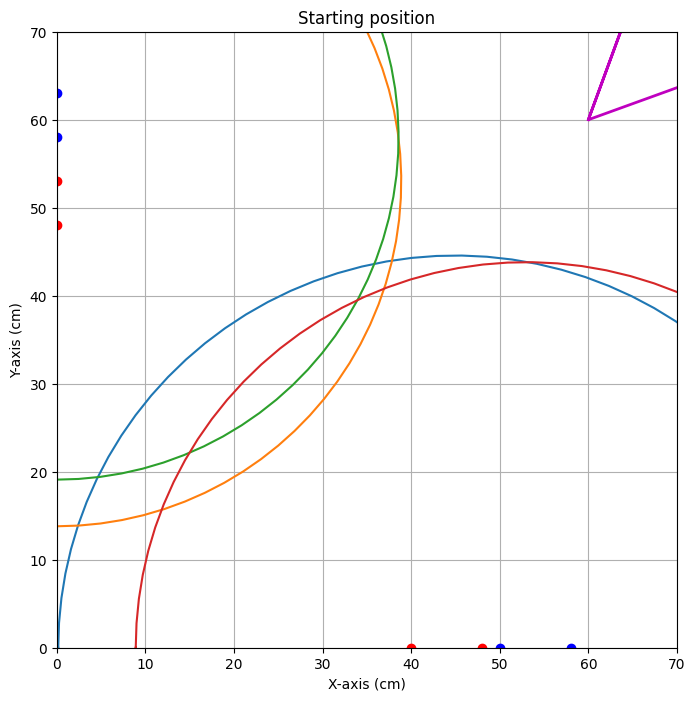


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=43.958


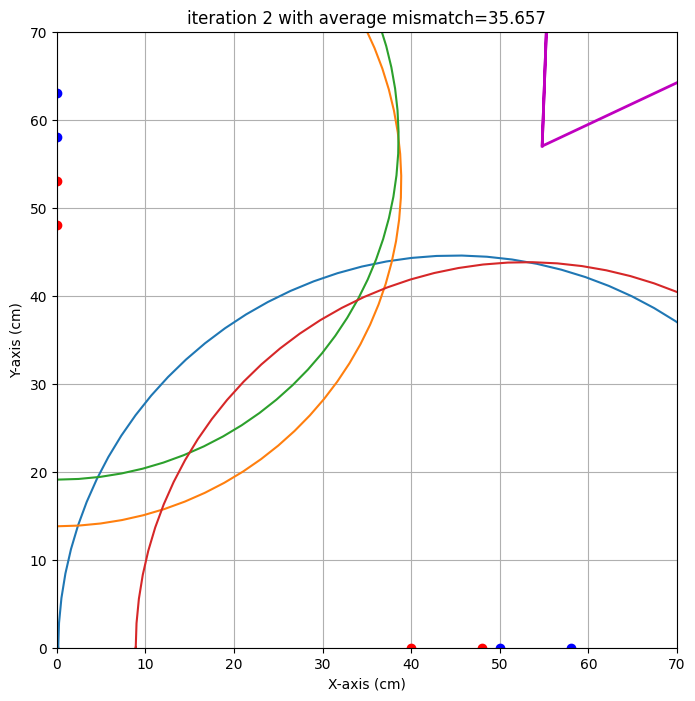

end iteration 2 with average mismatch=35.657


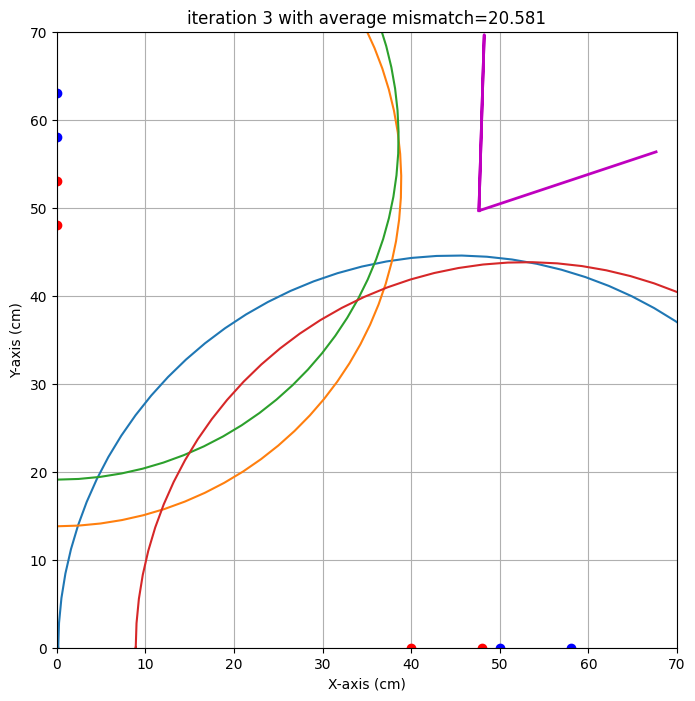

end iteration 3 with average mismatch=20.581


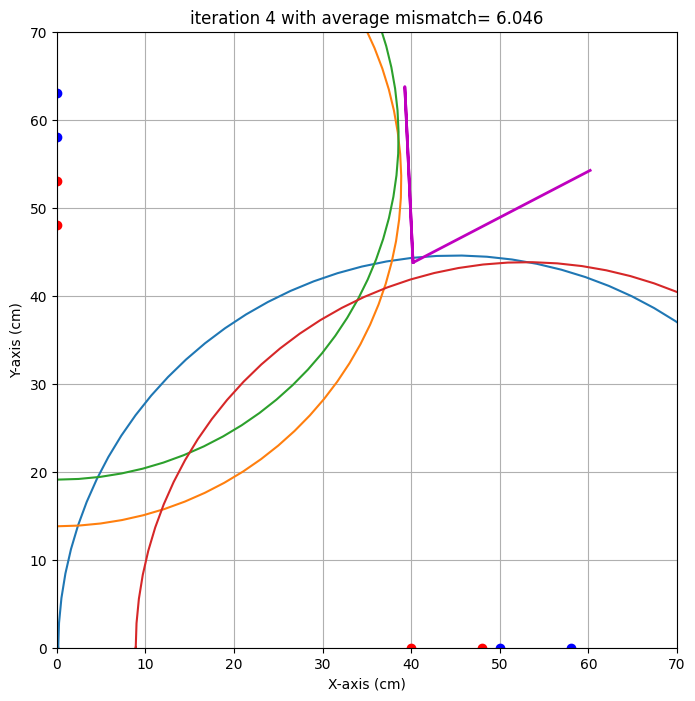

end iteration 4 with average mismatch= 6.046


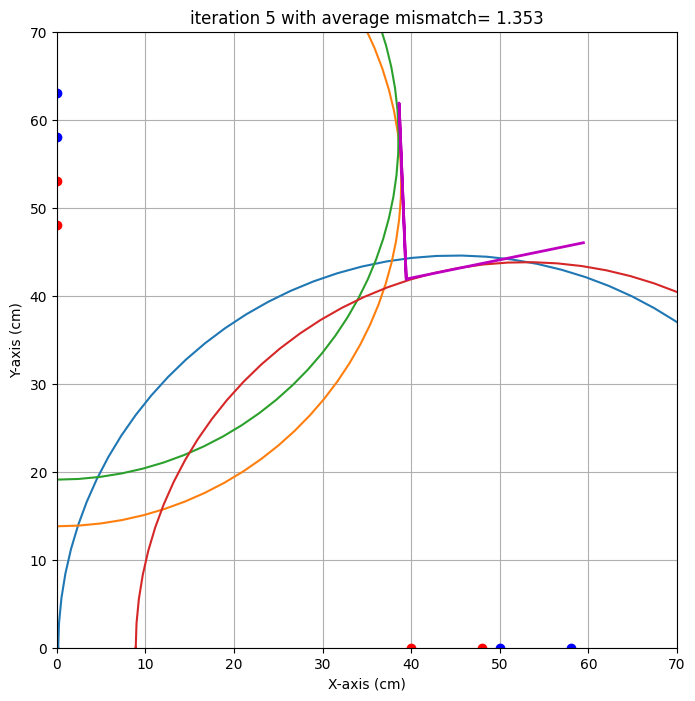

end iteration 5 with average mismatch= 1.353


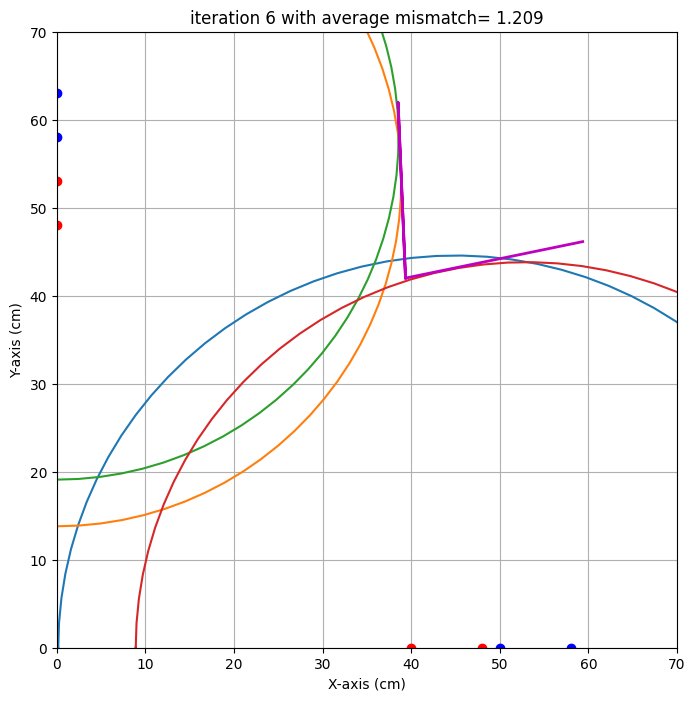

end iteration 6 with average mismatch= 1.209
end iteration 7 with average mismatch= 1.170
end iteration 8 with average mismatch= 1.166
end iteration 9 with average mismatch= 1.164
end iteration 10 with average mismatch= 1.164
end iteration 11 with average mismatch= 1.123
end iteration 12 with average mismatch= 1.087
end iteration 13 with average mismatch= 1.042


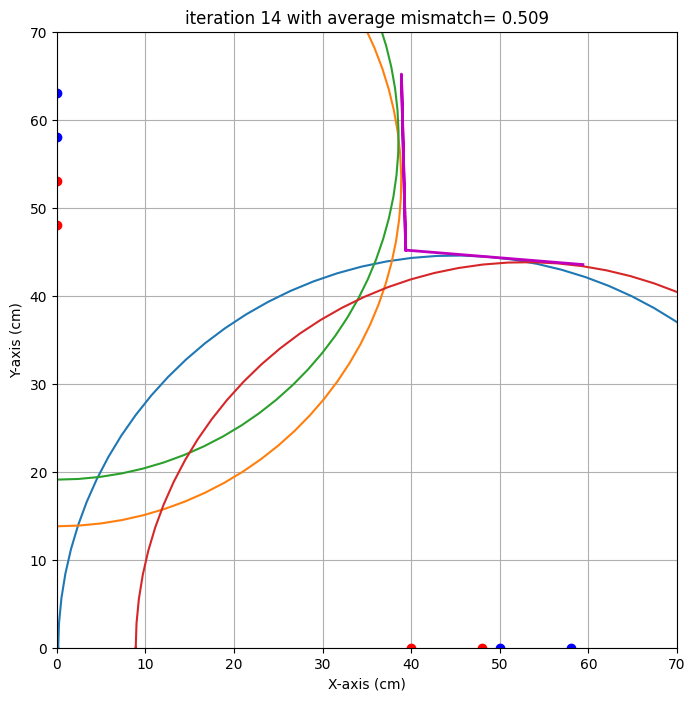

end iteration 14 with average mismatch= 0.509


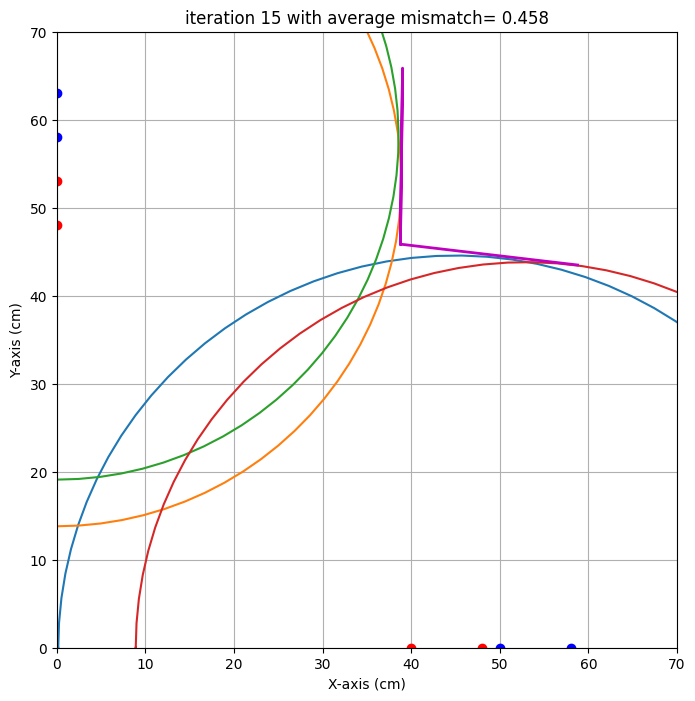

end iteration 15 with average mismatch= 0.458


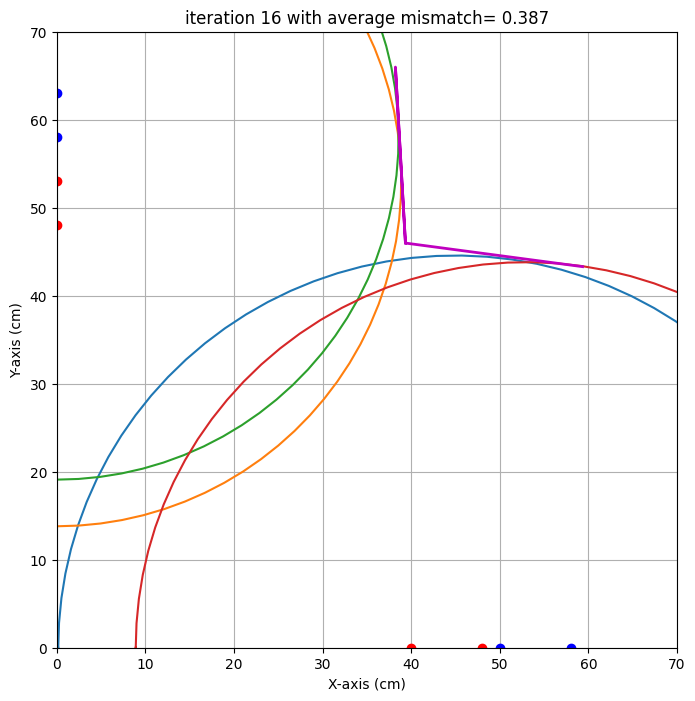

end iteration 16 with average mismatch= 0.387


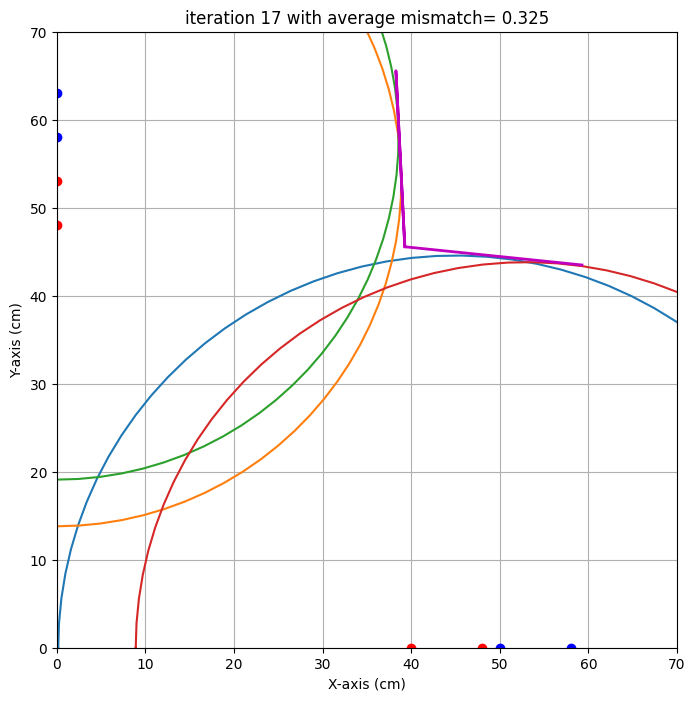

end iteration 17 with average mismatch= 0.325


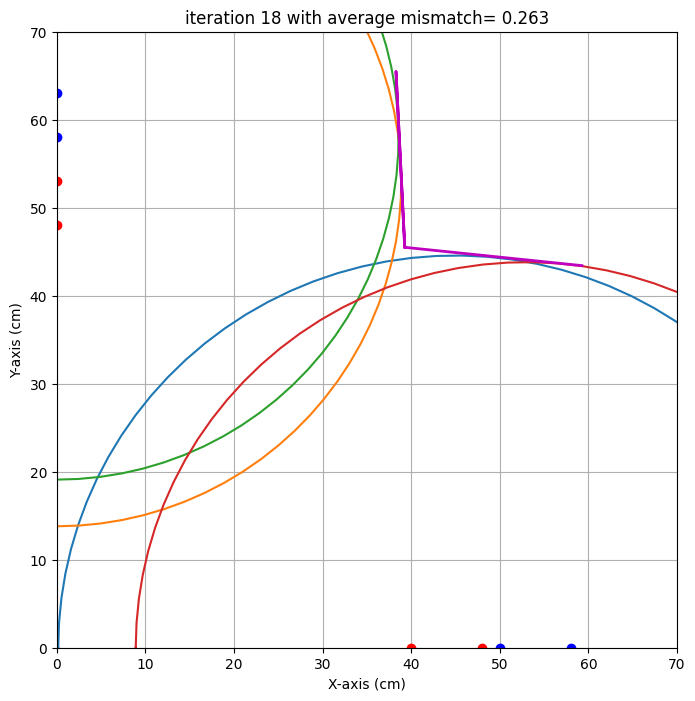

end iteration 18 with average mismatch= 0.263
end iteration 19 with average mismatch= 0.261
end iteration 20 with average mismatch= 0.261
end iteration 21 with average mismatch= 0.261
end iteration 22 with average mismatch= 0.261
end iteration 23 with average mismatch= 0.261
end iteration 24 with average mismatch= 0.241


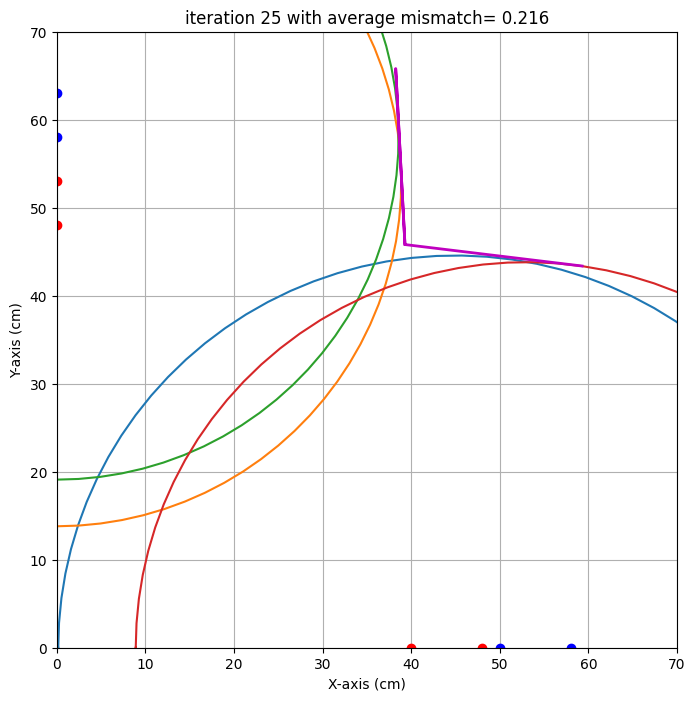

end iteration 25 with average mismatch= 0.216
end iteration 26 with average mismatch= 0.216
end iteration 27 with average mismatch= 0.216
end iteration 28 with average mismatch= 0.203
end iteration 29 with average mismatch= 0.188
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


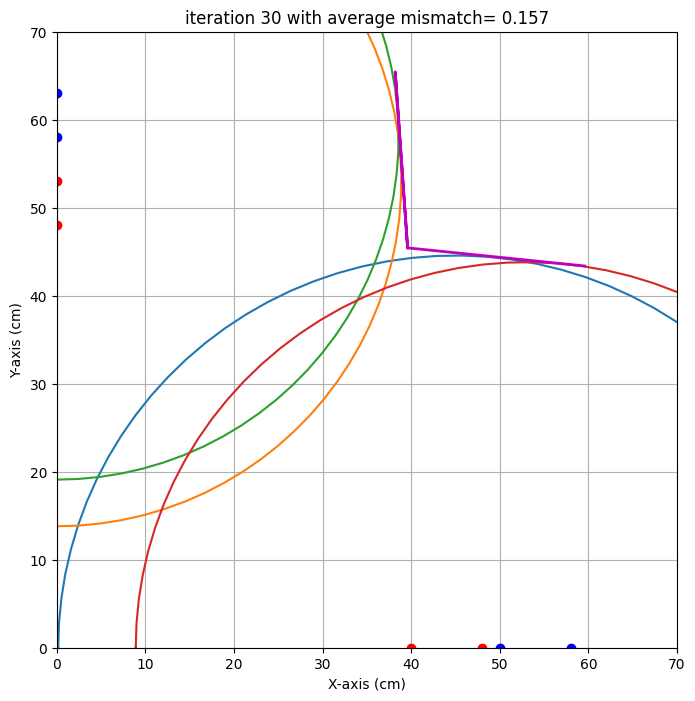

end iteration 30 with average mismatch= 0.157
###############################################################################
end of iteration  30
Best alpha=  -5.89 with uncertainty=   1.61
Best beta =  -4.00 with uncertainty=   7.87
Best x0   =  39.59 with uncertainty=   1.06
Best y0   =  45.44 with uncertainty=   0.41
###############################################################################


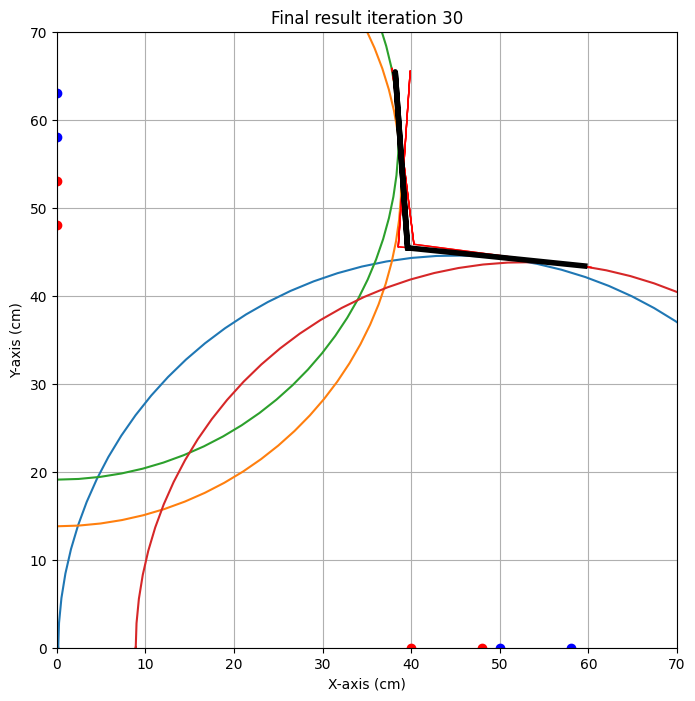

{'alpha': np.float64(-5.885860621122449), 'alpha_eps': np.float64(1.610771721055281), 'beta': np.float64(-3.9978449887805656), 'beta_eps': np.float64(7.868028971996268), 'x0': np.float64(39.59422447591959), 'x0_eps': np.float64(1.05563704312096), 'y0': np.float64(45.43790612323517), 'y0_eps': np.float64(0.4084622134300844)}
test locatie 
x0 target is : 40.0. Gevonden waarde: 39.6 cm met een standaardafwijking van 1.1 cm 
y0 target is : 45.0. Gevonden waarde: 45.4 cm met een standaardafwijking van 0.4 cm 
alpha target is : -8.0. Gevonden waarde: -5.9 graden met een standaardafwijking van 1.6 graad 
beta target is : -2.0. Gevonden waarde: -4.0 graden met een standaardafwijking van 7.9 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  40,
                    'y0':  45,
                    'alpha' :  -8,
                    'beta' :  -2
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [40,0,50,0, 89.7],
                    [0, 48, 0, 58, 78.4],
                    [0, 53, 0, 63, 77.8],
                    [48, 0, 58, 0, 88.2]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.

## leerdoel 1
#### algoritme [Christiaan]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="kris.jpeg" width="400">

<img src="iteratie_1.jpeg" width="400">

#### algoritme [Niels]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="niels.jpeg" width="400">

#### algoritme [Jelle]
Voeg een foto in van het algoritme van het derde groepslid
<img src="jelle.jpeg" width="400">

Figuur: ![Alt](iteratie_2.jpeg)
Figuur: ![Alt](iteratie_3.jpeg)


## leerdoel 2

In [13]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':  49,
           'y0': 49,
           'alpha' : 30,
           'beta' : 180,
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'kris' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 0, 45, 170],
    [45,0 , 35,0, 69.58],
    [45,0, 55, 0, 99.3],
    [0,45, 0,35,98.2],
    [0,45, 0,35, 89.2]
    ]),
       'niels' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,40,0, 162]
    [0, 50, 0, 60, 68.8], 
    [0, 40, 0, 50, 94],
    [35, 0, 40,0, 98],
    [20,0, 25,0, 97],
    [50,0,40,0,98.6]   
    ]),
       'jelle' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[40,0, 34,0, 179],
    #[0,34, 0, 40, 140],
    [0,50,0,56,62],
    [0,60, 0,56, 63],
    [50,0,59,0, 108],
    [40,0,64,0, 148]

    ])
      }

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  84.5
1   0  45   0  55  68.6
2   0  50   0  60  69.3
3  38   0  48   0  84.2


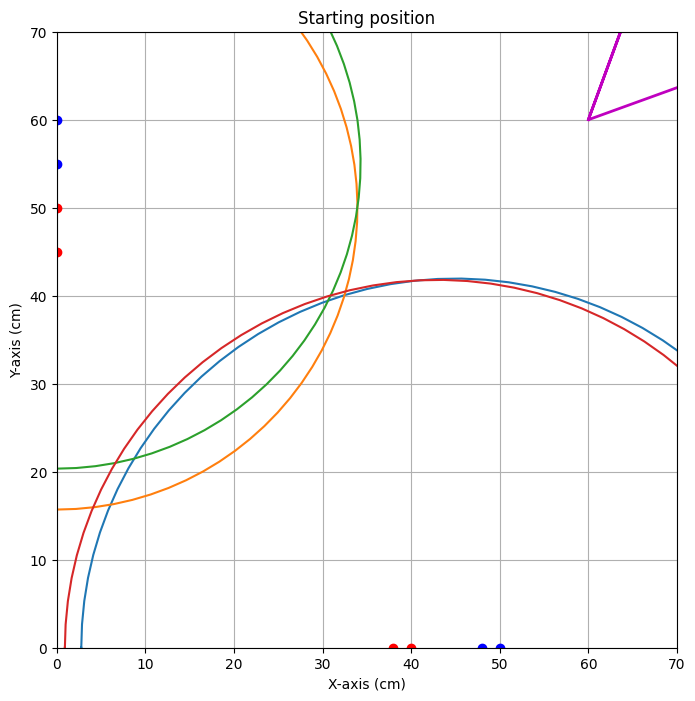


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.318


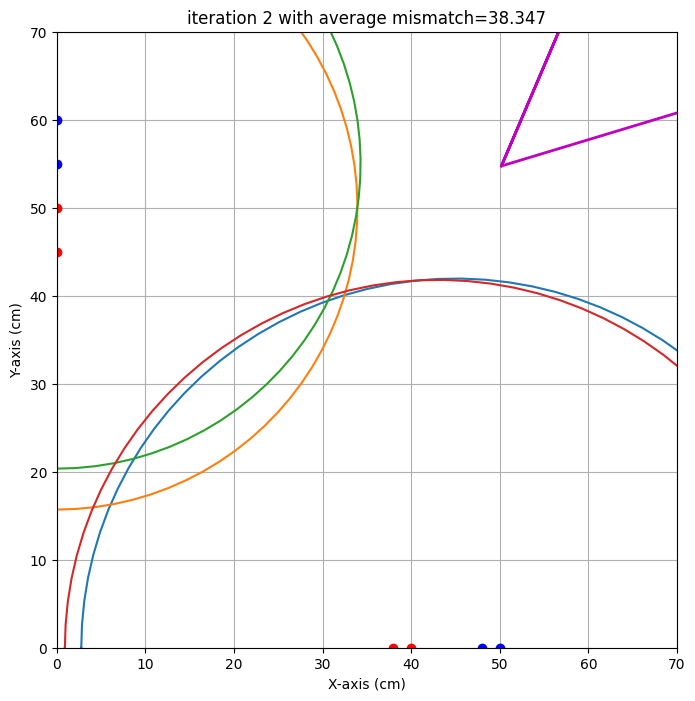

end iteration 2 with average mismatch=38.347


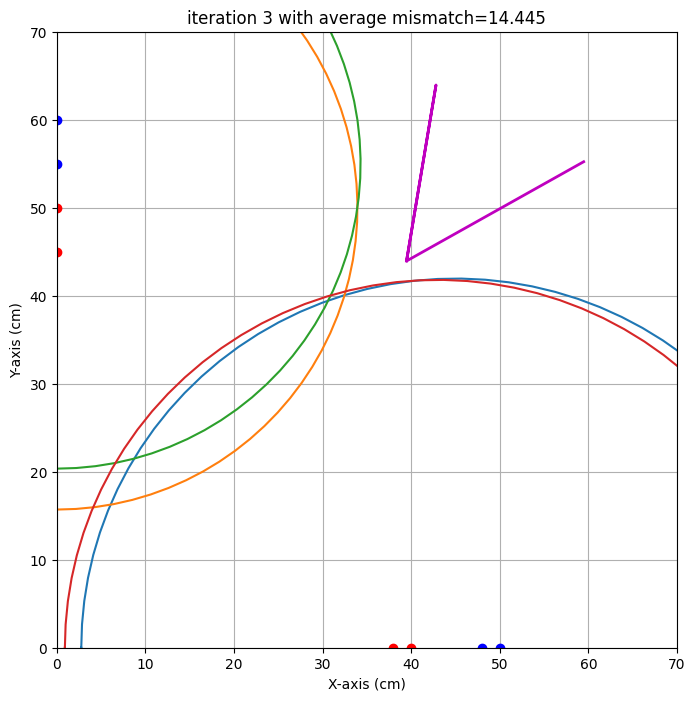

end iteration 3 with average mismatch=14.445


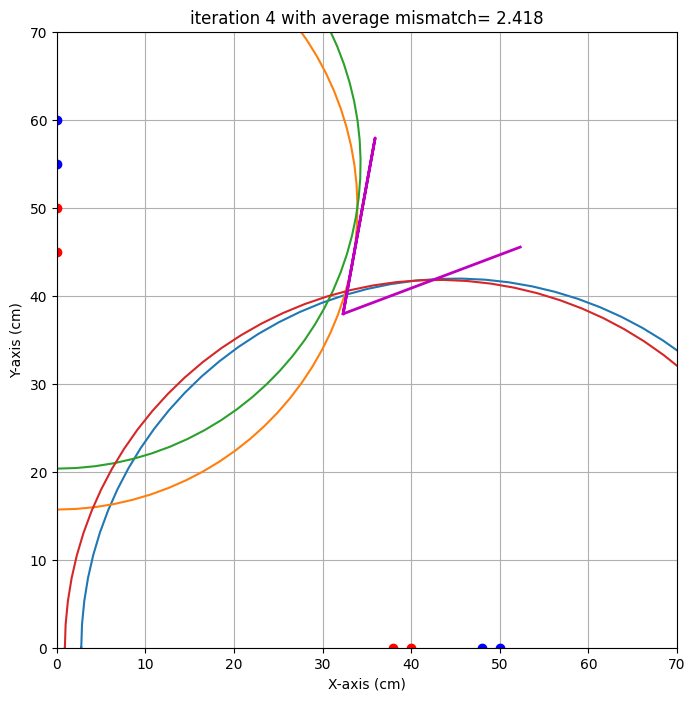

end iteration 4 with average mismatch= 2.418


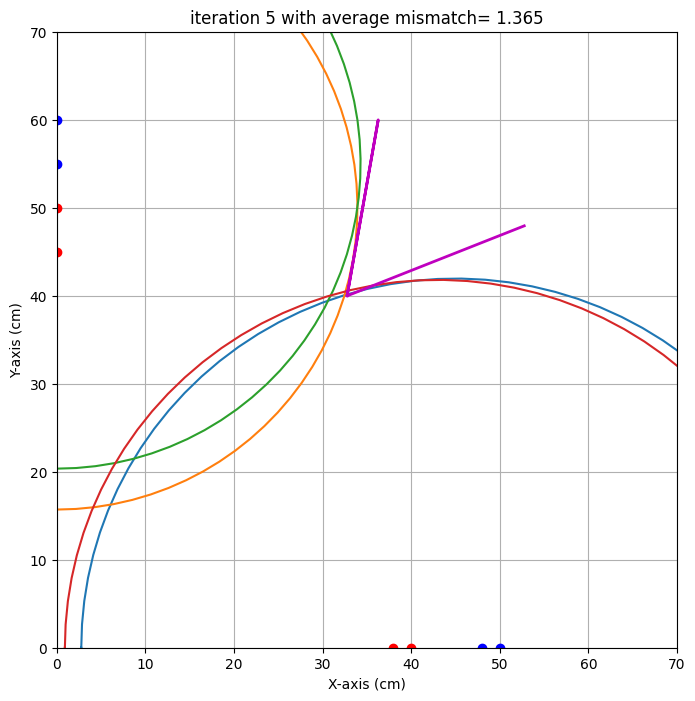

end iteration 5 with average mismatch= 1.365
end iteration 6 with average mismatch= 1.319
end iteration 7 with average mismatch= 1.297


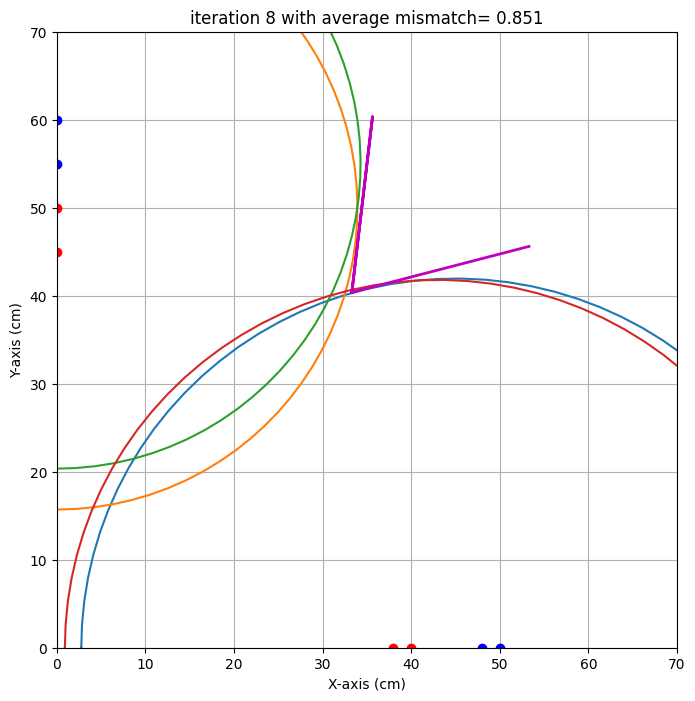

end iteration 8 with average mismatch= 0.851


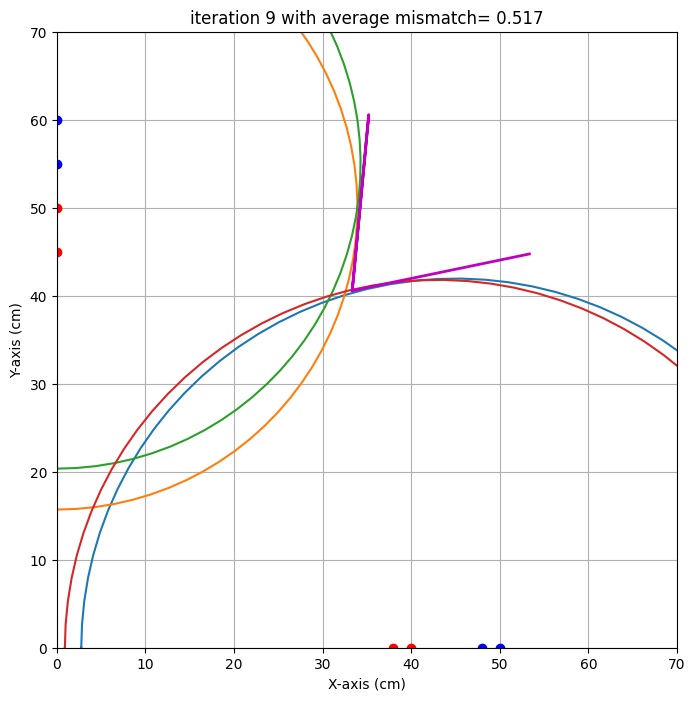

end iteration 9 with average mismatch= 0.517


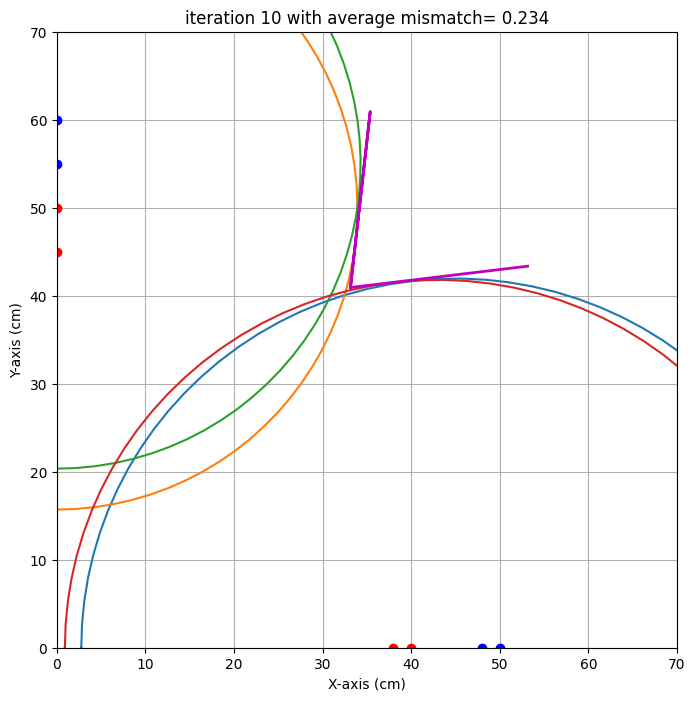

end iteration 10 with average mismatch= 0.234
end iteration 11 with average mismatch= 0.219


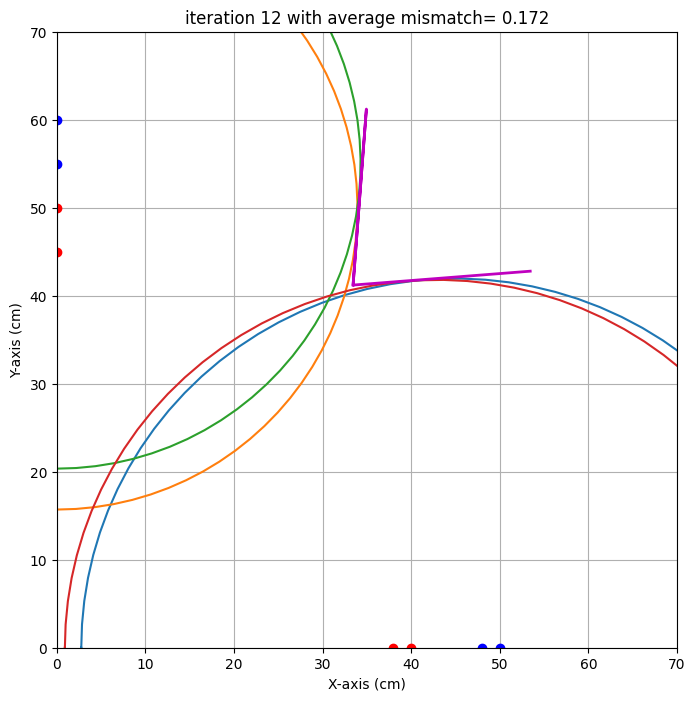

end iteration 12 with average mismatch= 0.172


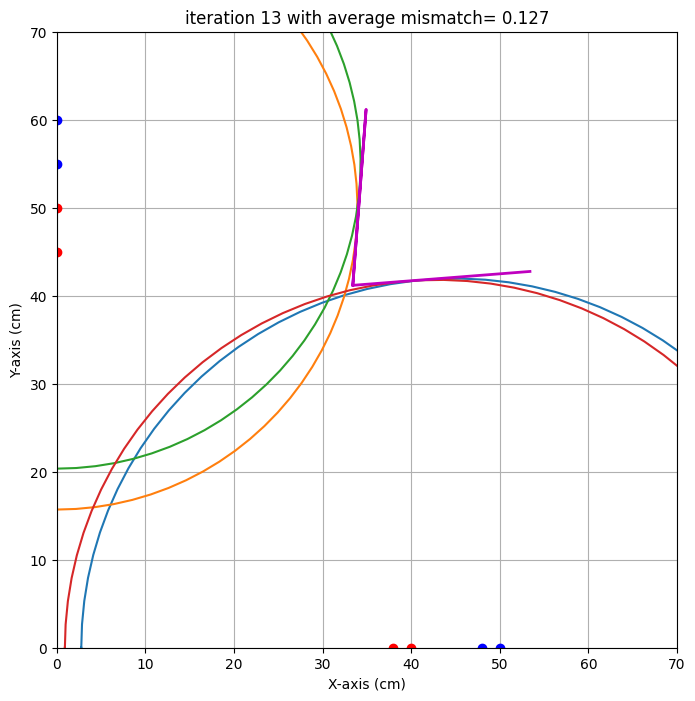

end iteration 13 with average mismatch= 0.127
end iteration 14 with average mismatch= 0.120
end iteration 15 with average mismatch= 0.117
end iteration 16 with average mismatch= 0.117
end iteration 17 with average mismatch= 0.116
end iteration 18 with average mismatch= 0.116
end iteration 19 with average mismatch= 0.116
end iteration 20 with average mismatch= 0.116
end iteration 21 with average mismatch= 0.116
end iteration 22 with average mismatch= 0.116
end iteration 23 with average mismatch= 0.116
end iteration 24 with average mismatch= 0.116
end iteration 25 with average mismatch= 0.116
end iteration 26 with average mismatch= 0.116
end iteration 27 with average mismatch= 0.116
end iteration 28 with average mismatch= 0.116
end iteration 29 with average mismatch= 0.116
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.116
###############################################################

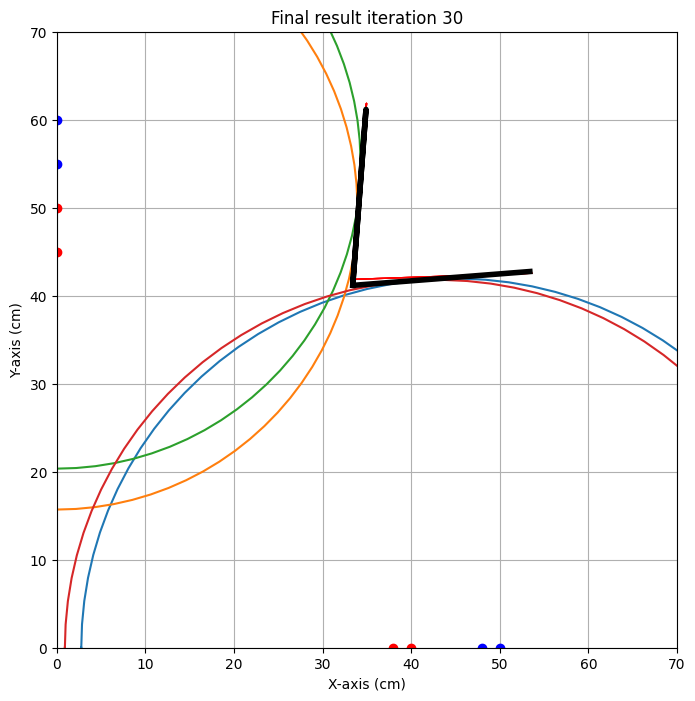

{'alpha': np.float64(4.50825354408683), 'alpha_eps': np.float64(2.5231141781086435), 'beta': np.float64(4.289055422424375), 'beta_eps': np.float64(0.4169943749773104), 'x0': np.float64(33.396921943980196), 'x0_eps': np.float64(0.2032323633922033), 'y0': np.float64(41.1728504328061), 'y0_eps': np.float64(0.690949346338833)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  92.3
1   0  50   0  60  68.0
2   0  55   0  65  65.7
3  45   0  55   0  91.7


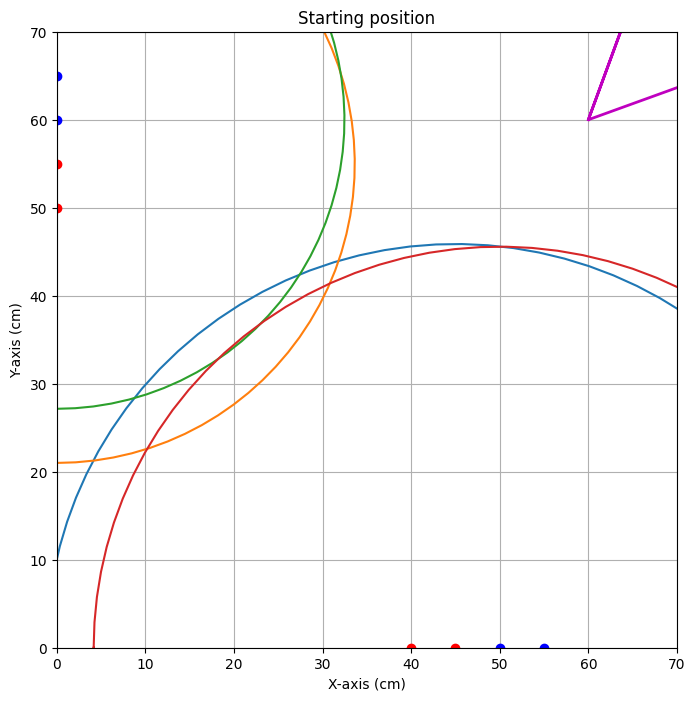


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=48.004


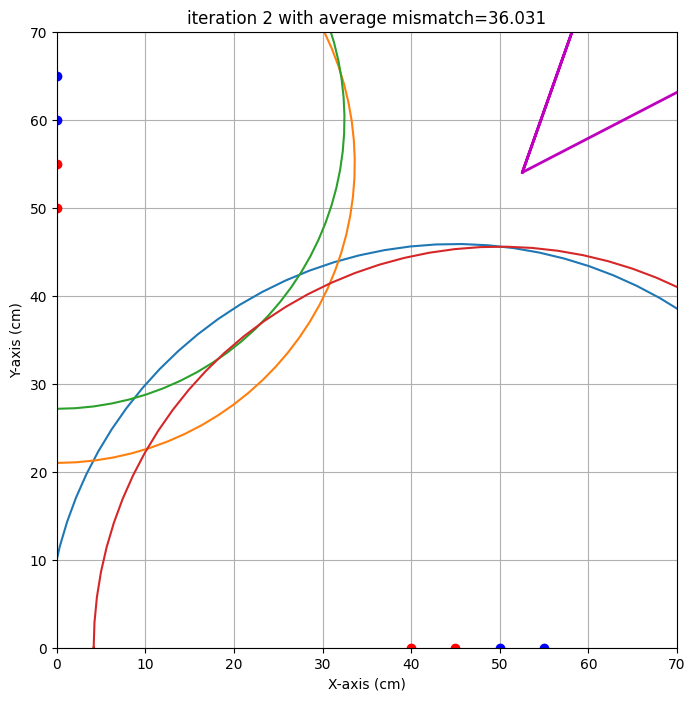

end iteration 2 with average mismatch=36.031


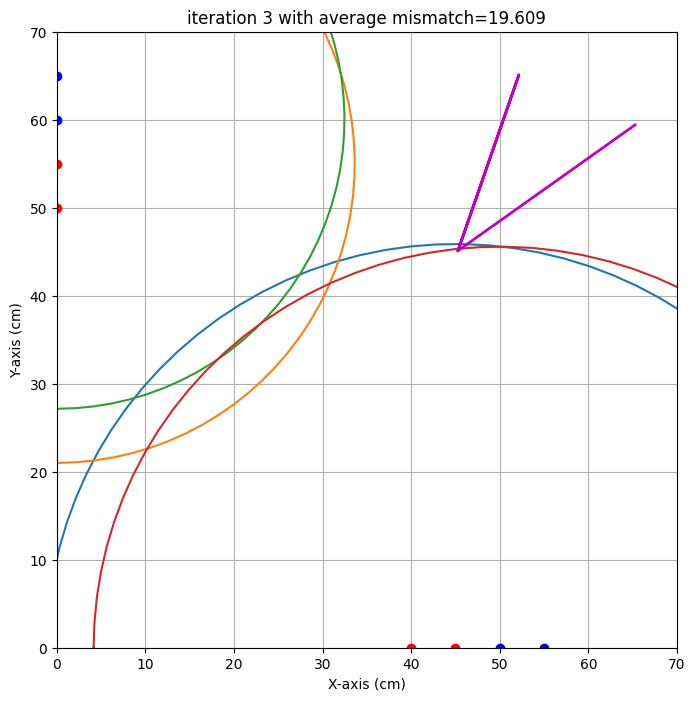

end iteration 3 with average mismatch=19.609


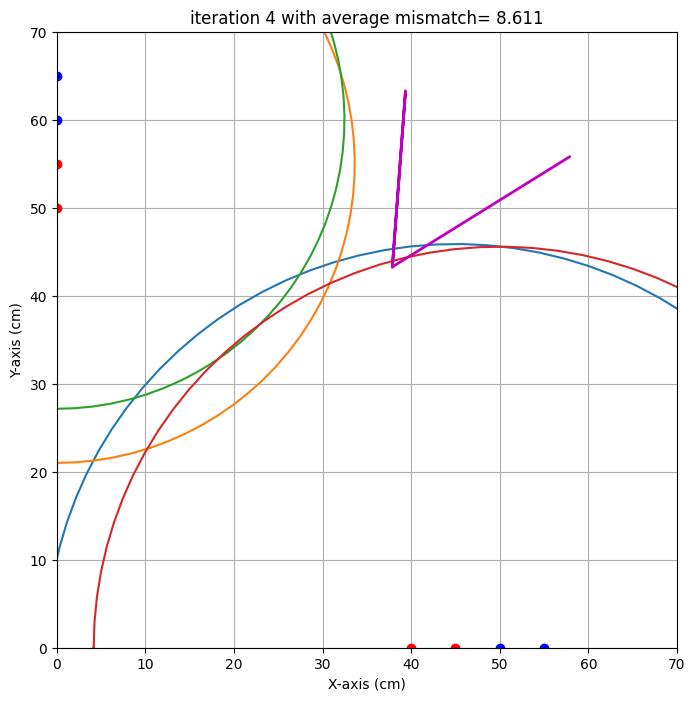

end iteration 4 with average mismatch= 8.611


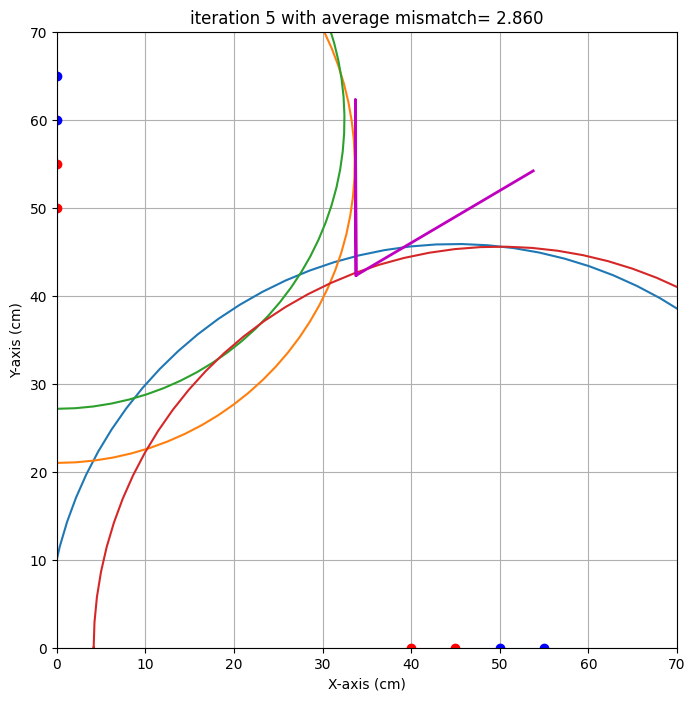

end iteration 5 with average mismatch= 2.860


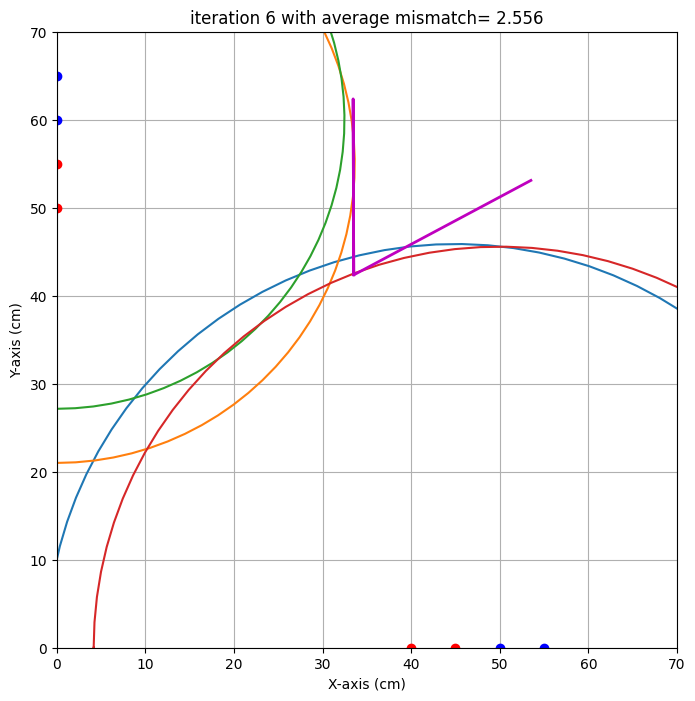

end iteration 6 with average mismatch= 2.556


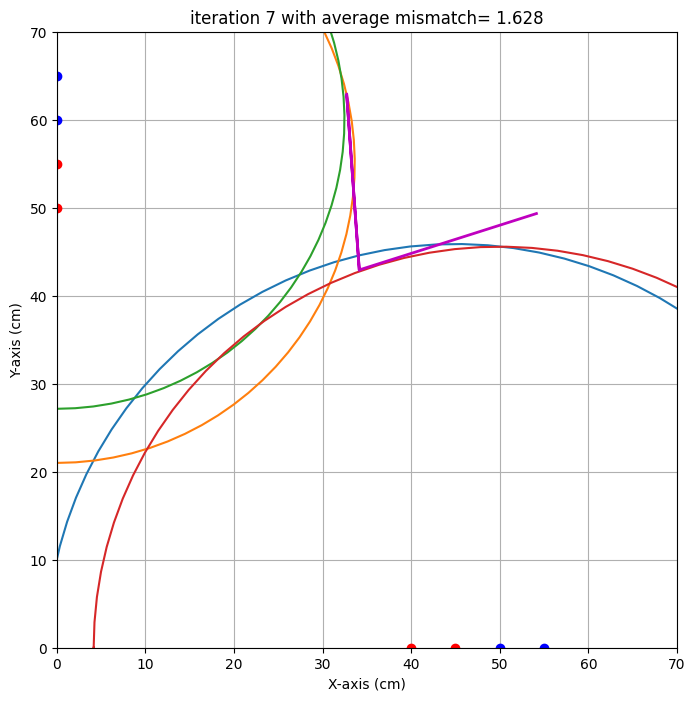

end iteration 7 with average mismatch= 1.628
end iteration 8 with average mismatch= 1.513
end iteration 9 with average mismatch= 1.380
end iteration 10 with average mismatch= 1.343
end iteration 11 with average mismatch= 1.307
end iteration 12 with average mismatch= 1.203


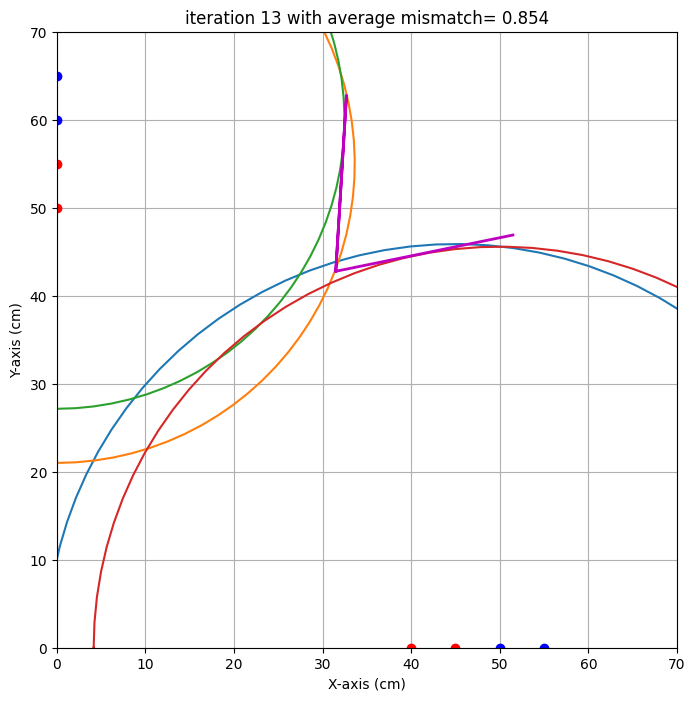

end iteration 13 with average mismatch= 0.854
end iteration 14 with average mismatch= 0.849
end iteration 15 with average mismatch= 0.849
end iteration 16 with average mismatch= 0.849
end iteration 17 with average mismatch= 0.849
end iteration 18 with average mismatch= 0.849
end iteration 19 with average mismatch= 0.849
end iteration 20 with average mismatch= 0.849
end iteration 21 with average mismatch= 0.849
end iteration 22 with average mismatch= 0.849
end iteration 23 with average mismatch= 0.849
end iteration 24 with average mismatch= 0.849
end iteration 25 with average mismatch= 0.837
end iteration 26 with average mismatch= 0.837
end iteration 27 with average mismatch= 0.837
end iteration 28 with average mismatch= 0.837
end iteration 29 with average mismatch= 0.837
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


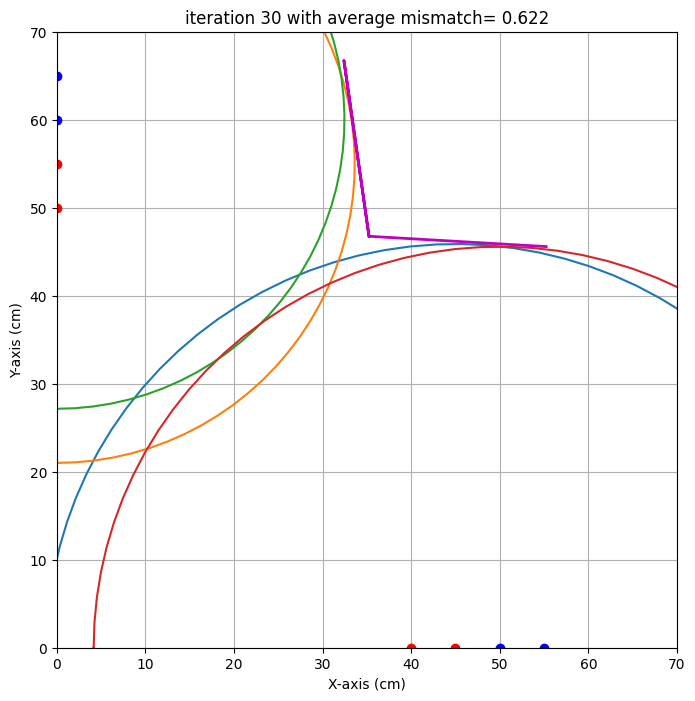

end iteration 30 with average mismatch= 0.622
###############################################################################
end of iteration  30
Best alpha=  -3.36 with uncertainty=  12.71
Best beta =  -8.08 with uncertainty=  10.25
Best x0   =  35.24 with uncertainty=   3.95
Best y0   =  46.76 with uncertainty=   3.17
###############################################################################


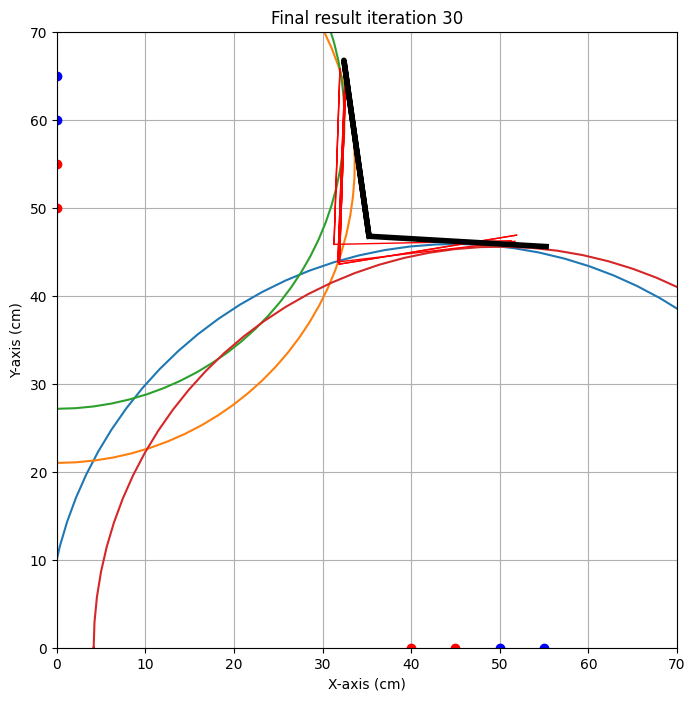

{'alpha': np.float64(-3.355809057771074), 'alpha_eps': np.float64(12.70996613137314), 'beta': np.float64(-8.075129183854504), 'beta_eps': np.float64(10.246058139193297), 'x0': np.float64(35.237847766043004), 'x0_eps': np.float64(3.9515401673310144), 'y0': np.float64(46.75657003334326), 'y0_eps': np.float64(3.1685172477003434)}
locatie 1 
x0 target is : 35.0. Gevonden waarde: 33.4 cm met een standaardafwijking van 0.2 cm 
y0 target is : 40.0. Gevonden waarde: 41.2 cm met een standaardafwijking van 0.7 cm 
alpha target is : 20.0. Gevonden waarde: 4.5 graden met een standaardafwijking van 2.5 graad 
beta target is : 10.0. Gevonden waarde: 4.3 graden met een standaardafwijking van 0.4 graad 

locatie 2 
x0 target is : 36.0. Gevonden waarde: 35.2 cm met een standaardafwijking van 4.0 cm 
y0 target is : 46.0. Gevonden waarde: 46.8 cm met een standaardafwijking van 3.2 cm 
alpha target is : 9.0. Gevonden waarde: -3.4 graden met een standaardafwijking van 12.7 graad 
beta target is : 3.0. Gevo

In [14]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 35,
                    'y0':40,
                    'alpha' : 20,
                    'beta' : 10,},
           'locatie 2':{'x0': 36,
                    'y0':46,
                    'alpha' : 9,
                    'beta' : 3}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40,0,50,0,84.5],
    [0,45, 0,55,68.6],
    [0,50, 0, 60, 69.3],
    [38,0, 48, 0, 84.2]

    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40, 0, 50, 0, 92.3],
    [0,50, 0,60, 68],
    [0,55, 0,65, 65.7],
    [45, 0, 55, 0, 91.7]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))